# Peak-conditioned guided design — figures

Every figure for the experiment in this folder, in the order a write-up would use them: the
sequence → peak landscape the models have to learn, the split they are trained under, the
architecture search that picks them, how well the two picked models actually predict, and finally
what the guided search does with them.

1. **Landscape ruggedness** — the curated 758 laid out in sequence space, with excitation and
   emission raised into the third dimension so the map becomes a terrain. Static first, then the
   same two terrains as rotatable Plotly scenes.
2. **Emission by ancestral lineage** — what each natural FP lineage's emission range actually
   contains, and how little ancestry settles the colour.
3. **The nested split** — how the surrogate's data sits entirely inside the oracle's training pool,
   and what that costs.
4. **Surrogate architecture sweep** (ESM-2 embeddings) and **5. oracle architecture sweep**
   (ProstT5), each against its own nearest-neighbour null.
6. **Held-out predictions** for the deployed surrogate and **7.** for the oracle.
8. **Guided design, cycle by cycle** — the guided arm against an unguided control on task set 2,
   and how often a single run improves on its scaffold at all.

Each section is one figure with its caption underneath. Figures are written to `figures/`.


In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import hashlib
import json
import os

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import arcadia_pycolor as apc

# Fonts and the curated/embedding caches are produced under dataset_pipeline/ and are shared,
# split-independent -- read from there unchanged. This experiment's own split and models are
# local (data/dual_splits.csv, trained_models/), see DUAL_SPLITS below.
DP = "../dataset_pipeline"
FONTS = f"{DP}/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

PROT_JSON = f"{DP}/../fpbase-extractor/fpbase_output/fpbase_proteins.json"
EMB_NPY = f"{DP}/data/fpbase_esm2_650M_max.npy"
EMB_META = f"{DP}/data/fpbase_esm2_650M_max.meta.json"
CURATED = f"{DP}/data/peak/curated"
DUAL_SPLITS = "data/dual_splits.csv"   # this experiment's own nested split, NOT dataset_pipeline's
FIGDIR = "figures"                     # this folder's own figures, as in the sibling notebooks

assert os.path.exists(EMB_NPY), "run `python embed_fpbase_maxpool.py` in dataset_pipeline/ first"
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The same helpers the curation notebook uses. Panel geometry is expressed in the guide's pixels
(Full_wide 1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib
point is exactly one style-guide pixel.

One departure: excitation and emission are shaded on a **single shared** magma normalization
spanning both, rather than each panel getting its own scale. A given colour therefore means the
same wavelength in both panels, and the two terrains can be read against each other.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
# A third data colour, for the one series that is neither of the two conditions: the unguided
# control arm of Section 8, which has to read as the same series on both sides of a figure.
CONTROL = str(apc.aster)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

# Continuous scale for wavelength. Magma is Arcadia's default gradient; its cool-to-warm run keeps
# short and long wavelengths reading the intuitive way round. The very top of the ramp is dropped
# because it approaches the page white and would make the reddest proteins disappear.
PEAK_CMAP = LinearSegmentedColormap.from_list(
    "apc:magma_dots", apc.gradients.magma.to_mpl_cmap()(np.linspace(0.04, 0.86, 256))
)


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def panel_letter_3d(ax, letter, x=0.02, y=0.84):
    """Panel letter on a 3-D axes.

    Axes3D has no annotate in axes coordinates, so use text2D. A 3-D axes also insets its drawn
    cube well within its own bbox, so the letter sits lower than the 2-D convention would put it,
    which keeps it beside the plot rather than adrift in the margin.
    """
    ax.text2D(x, y, letter, transform=ax.transAxes, ha="left", va="bottom", **PANEL_LETTER)


# The same role one size down, for notes that sit inside a crowded panel rather than beside it.
ANNOT = dict(fontsize=11, fontweight="ultralight", color=str(apc.charcoal))


def key(ax, handles, **kw):
    """A frameless key. style_plot must already have run on the axes: calling it afterwards
    re-triggers apc's style_legend, which draws a stray rule above the entries at 144 dpi."""
    leg = ax.legend(handles=handles, frameon=False, fontsize=10.5, handletextpad=0.4,
                    labelspacing=0.35, borderaxespad=0.2, **kw)
    apc.mpl.capitalize_legend_text(leg)
    return leg


## 1. Landscape ruggedness

### 1.1 Rebuild the curation notebook's sequence-space map

The layout is taken from Figure 1 of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) and is reproduced here
**exactly**: the same max-pooled ESM-2 embedding of all 990 sequenced FPbase proteins, standardized,
compressed to 50 principal components, then t-SNE with `init="pca"`, perplexity 30 and
`random_state=0`.

The fit deliberately stays on all 990. Dropping the excluded proteins *before* the fit would move
every surviving point, because t-SNE's layout depends on the whole neighbour graph; keeping them in
and discarding their coordinates afterwards means each of the 758 sits precisely where the curation
figure put it. So this is a subset of that map, not a new one.

Membership is matched **on the sequence** rather than the slug, since stage C of the pipeline
collapses each group of identical sequences to one representative row and slug matching would miss
the duplicates that were folded away.

In [3]:
proteins = json.load(open(PROT_JSON))
meta = json.load(open(EMB_META))

prot = pd.DataFrame([
    {
        "slug": p.get("slug", ""),
        "name": p.get("name", ""),
        "organism": p.get("parent_organism") or "",
        "seq": (p.get("seq") or "").strip().upper(),
    }
    for p in proteins
    if (p.get("seq") or "").strip()
])

# embed_fpbase_maxpool.py records an md5 over the exact sequence list it embedded; rebuilding the
# same list here and checking it guarantees each embedding row still lines up with a row of prot.
md5 = hashlib.md5("\x00".join(prot.seq).encode()).hexdigest()
assert md5 == meta["seq_md5"], "embedding cache is stale -- rerun embed_fpbase_maxpool.py"

Z = np.load(EMB_NPY)
assert len(Z) == len(prot)

curated = pd.read_csv(f"{CURATED}/peaks_assignments.csv").sort_values("index").reset_index(drop=True)
prot["is_true_fp"] = prot.seq.isin(set(curated.seq))

print(f"{len(proteins)} FPbase entries | {len(prot)} with a sequence | "
      f"embedding {Z.shape} ({meta['model']}, layer {meta['layer']}, {meta['pooling']}-pooled)")
print(f"curated peak set: {len(curated)} rows, {prot.is_true_fp.sum()} of the {len(prot)} "
      f"sequenced proteins map into it")

1041 FPbase entries | 990 with a sequence | embedding (990, 1280) (esm2_t33_650M_UR50D, layer 33, max-pooled)
curated peak set: 758 rows, 758 of the 990 sequenced proteins map into it


In [4]:
Zstd = StandardScaler().fit_transform(Z)
pca50 = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca50.fit_transform(Zstd)
print(f"50-PC embedding: {Z50.shape} ({pca50.explained_variance_ratio_.sum():.1%} variance retained)")

xy = TSNE(n_components=2, metric="euclidean", init="pca", perplexity=30,
          learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x"], prot["y"] = xy[:, 0], xy[:, 1]

# Keep only the curated rows, in peaks.npy order, so x/y/ex/em stay index-aligned with the
# rest of the pipeline (dual_splits.csv, the embedding caches, peaks_assignments.csv).
seq_to_row = {s: i for i, s in enumerate(prot.seq)}
rows = curated.seq.map(seq_to_row)
assert rows.notna().all(), "every curated sequence should be in the embedding table"
rows = rows.astype(int).to_numpy()
assert len(set(rows)) == len(rows) == len(curated), "curated rows must map one-to-one"

x, y = prot.x.to_numpy()[rows], prot.y.to_numpy()[rows]
ex = curated.ex_max.to_numpy(float)
em = curated.em_max.to_numpy(float)
names = curated.name.to_numpy()

print(f"t-SNE fitted on all {len(prot)}, kept the {len(x)} curated")
print(f"excitation {ex.min():.0f}-{ex.max():.0f} nm | emission {em.min():.0f}-{em.max():.0f} nm")

50-PC embedding: (990, 50) (84.3% variance retained)


t-SNE fitted on all 990, kept the 758 curated
excitation 343-611 nm | emission 414-684 nm


### 1.2 Turn the point cloud into a terrain

With the map as the ground plane, each protein's peak becomes a height, and the 758 points become
a surface over Delaunay triangles of the t-SNE coordinates.

Delaunay triangulates the *convex hull*, so it happily spans the empty gaps between clusters and
would draw sheer walls where there is simply no data. Every triangle whose longest edge exceeds the
90th percentile is therefore masked out. The threshold is a heuristic and it is the one dial in the
figure: raising it bridges more gaps with invented surface, lowering it fragments real
neighbourhoods. It is reported below so the choice stays visible.

Relief is not smoothed. Interpolating or averaging the heights would flatten exactly the feature
this figure exists to show, so neighbouring sequences with very different peaks stay as the near
vertical faces they are.

In [5]:
EDGE_PCTL = 90                    # drop triangles whose longest edge is above this percentile

tri_all = mtri.Triangulation(x, y)
t = tri_all.triangles
# longest side of each triangle, from the three (vertex, next vertex) pairs
edge_len = np.sqrt((x[t] - x[np.roll(t, 1, axis=1)]) ** 2
                   + (y[t] - y[np.roll(t, 1, axis=1)]) ** 2).max(axis=1)
edge_cut = np.percentile(edge_len, EDGE_PCTL)

surf = mtri.Triangulation(x, y)
surf.set_mask(edge_len > edge_cut)

# One scale for both panels so a colour and a height mean the same thing in each.
PEAK_NORM = Normalize(vmin=min(ex.min(), em.min()), vmax=max(ex.max(), em.max()))
ZLIM = (PEAK_NORM.vmin - 10, PEAK_NORM.vmax + 10)


def robust_lims(v, pad=0.04):
    """Axis limits covering the bulk, so a few stray points cannot shrink the terrain."""
    lo, hi = np.percentile(v, [1, 99])
    margin = (hi - lo) * pad
    return lo - margin, hi + margin


XLIM, YLIM = robust_lims(x), robust_lims(y)

print(f"{len(t)} Delaunay triangles | longest edge <= {edge_cut:.1f} keeps "
      f"{(~surf.mask).sum()} ({(~surf.mask).mean():.0%})")
print(f"shared height scale: {PEAK_NORM.vmin:.0f}-{PEAK_NORM.vmax:.0f} nm")

1504 Delaunay triangles | longest edge <= 8.9 keeps 1353 (90%)
shared height scale: 343-684 nm


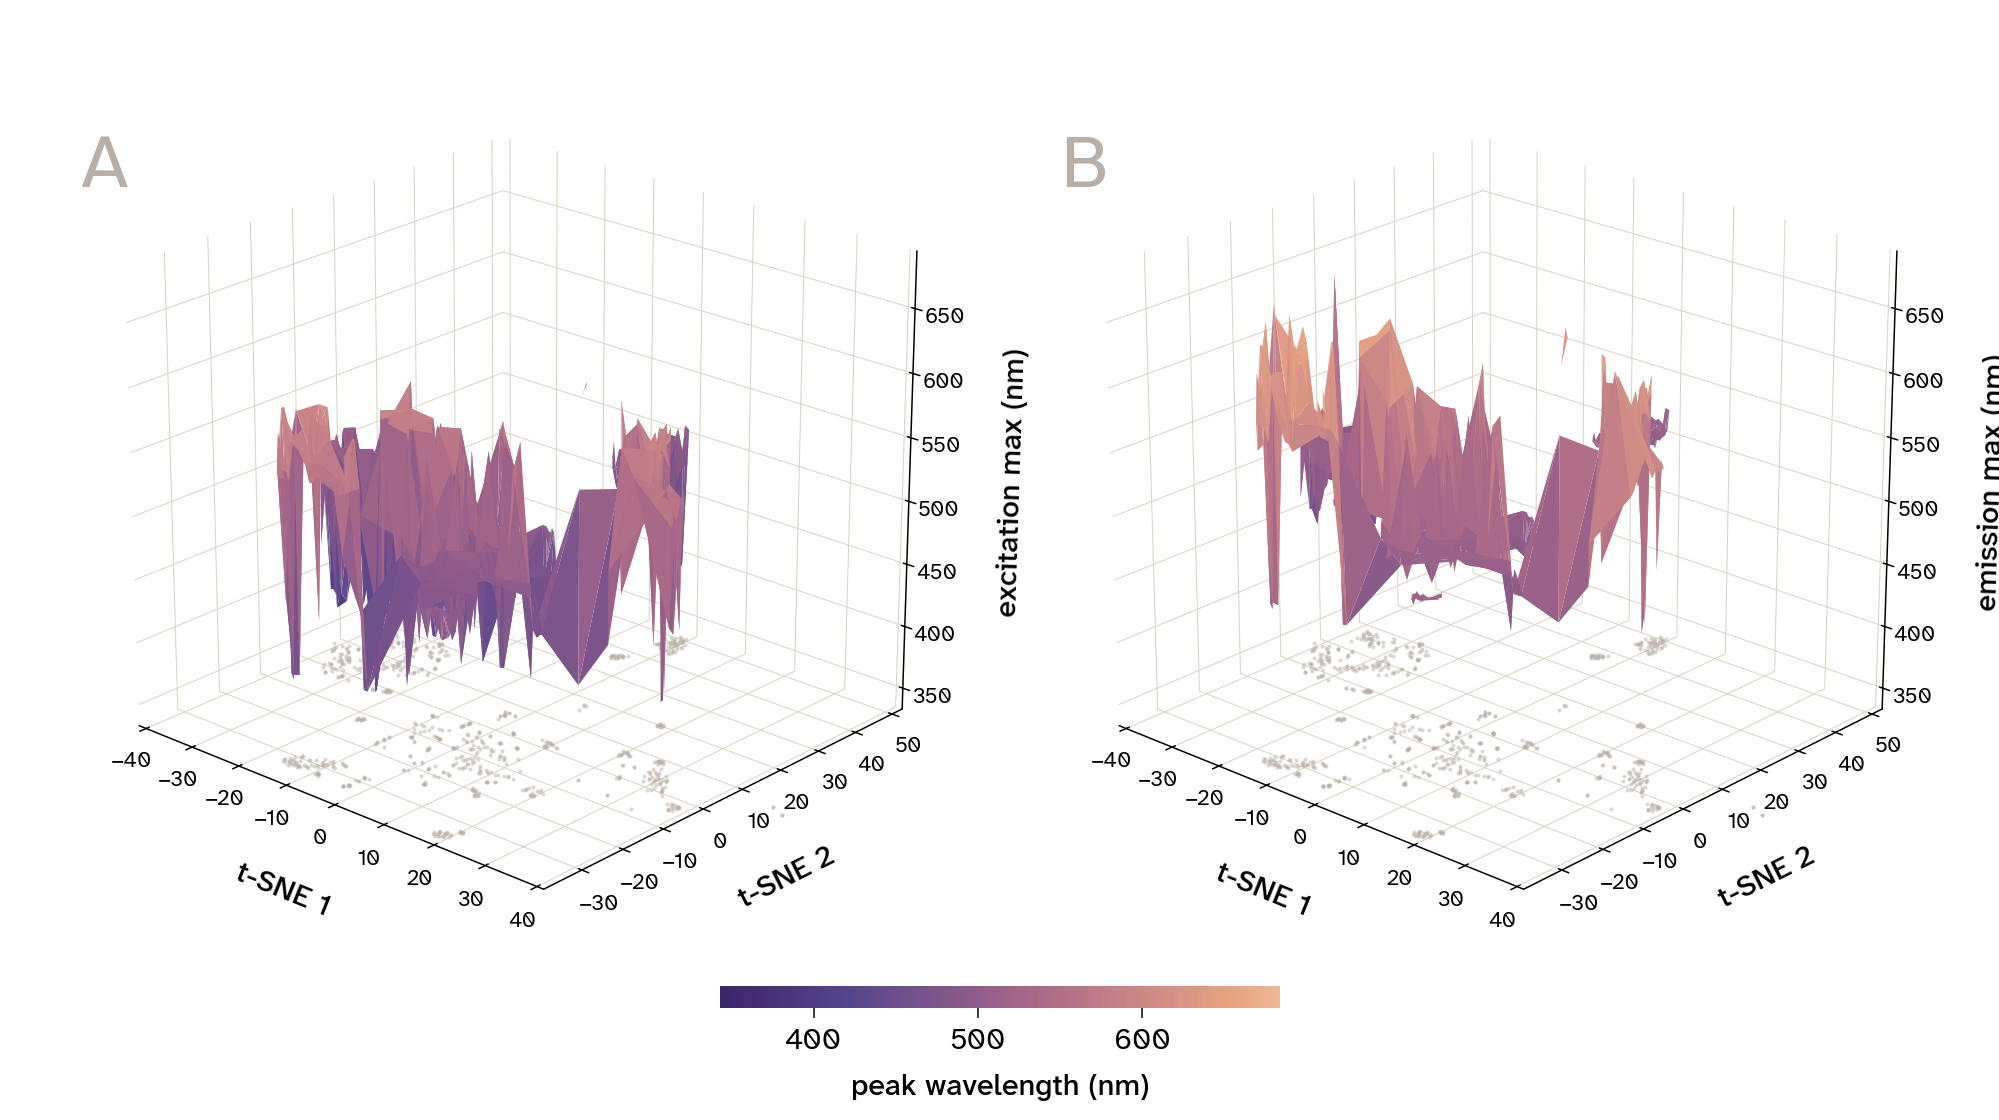

2103 edges in the drawn mesh
  |dex| median  18 nm   p90 102 nm
  |dem| median  10 nm   p90  74 nm
  0.5(|dex|+|dem|): median 16.5 nm | 39% under 10 nm | 23% over 50 nm | max 218 nm

steepest faces in the terrain:
    218 nm   mNeptune684            (604, 684)   vs   mTagBFP2               (399, 454)
    216 nm   mNeptune684            (604, 684)   vs   secBFP2                (399, 456)
    212 nm   mCarmine               (603, 675)   vs   mTagBFP2               (399, 454)
    206 nm   Electra1               (402, 454)   vs   mGarnet2               (598, 671)
    206 nm   Electra2               (403, 454)   vs   mGarnet2               (598, 671)


In [6]:
ELEV, AZIM = 22, -48              # low enough that the cliff faces are seen edge-on
FIG_H = 560

fig = plt.figure(figsize=(FULL_WIDE * PX, FIG_H * PX))
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.15, top=0.95, wspace=0.0)

for i, (z, what, letter) in enumerate([(ex, "excitation", "A"), (em, "emission", "B")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")

    # the t-SNE map itself, dropped onto the floor so the terrain keeps its footprint
    ax.scatter(x, y, zs=ZLIM[0], zdir="z", s=4, c=NEUTRAL, alpha=0.5, depthshade=False)
    ax.plot_trisurf(surf, z, cmap=PEAK_CMAP, norm=PEAK_NORM,
                    linewidth=0, edgecolor="none", antialiased=True)

    ax.set(xlim=XLIM, ylim=YLIM, zlim=ZLIM,
           xlabel="t-SNE 1", ylabel="t-SNE 2", zlabel=f"{what} max (nm)")
    ax.set_box_aspect((1, 1, 0.9))
    ax.view_init(elev=ELEV, azim=AZIM)
    # the guide's 0.75pt rules; Axes3D panes are drawn instead of spines
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor(NEUTRAL_SOFT)
        axis.pane.set_alpha(1.0)
        axis._axinfo["grid"].update(color=NEUTRAL_SOFT, linewidth=0.5)
    ax.tick_params(labelsize=11, pad=1)
    panel_letter_3d(ax, letter)

# One shared colourbar: the height scale is common to both panels, so one key serves them both.
cax = fig.add_axes([0.36, 0.10, 0.28, 0.020])
bar = fig.colorbar(plt.cm.ScalarMappable(norm=PEAK_NORM, cmap=PEAK_CMAP),
                   cax=cax, orientation="horizontal")
bar.set_label("peak wavelength (nm)")
bar.outline.set_visible(False)
apc.mpl.set_colorbar_ticklabel_monospaced(cax)

fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.svg")
fig.savefig(f"{FIGDIR}/landscape_ruggedness_tsne.png", dpi=200)
plt.show()

# Relief along the drawn mesh: how far the peaks move between two proteins the surface joins.
# This is the terrain's steepness expressed as a number, over the same edges the eye is reading.
kept = surf.triangles[~surf.mask]
sides = np.concatenate([kept[:, [0, 1]], kept[:, [1, 2]], kept[:, [2, 0]]])
pairs = np.unique(np.sort(sides, axis=1), axis=0)      # each shared side counted once
i, j = pairs[:, 0], pairs[:, 1]
d_ex, d_em = np.abs(ex[i] - ex[j]), np.abs(em[i] - em[j])
d_peak = 0.5 * (d_ex + d_em)

print(f"{len(pairs)} edges in the drawn mesh")
print(f"  |dex| median {np.median(d_ex):3.0f} nm   p90 {np.percentile(d_ex, 90):3.0f} nm")
print(f"  |dem| median {np.median(d_em):3.0f} nm   p90 {np.percentile(d_em, 90):3.0f} nm")
print(f"  0.5(|dex|+|dem|): median {np.median(d_peak):.1f} nm | "
      f"{100 * np.mean(d_peak < 10):.0f}% under 10 nm | {100 * np.mean(d_peak > 50):.0f}% over 50 nm | "
      f"max {d_peak.max():.0f} nm")
print("\nsteepest faces in the terrain:")
for k in np.argsort(-d_peak)[:5]:
    print(f"  {d_peak[k]:5.0f} nm   {names[i[k]][:22]:22} ({ex[i[k]]:.0f}, {em[i[k]]:.0f})"
          f"   vs   {names[j[k]][:22]:22} ({ex[j[k]]:.0f}, {em[j[k]]:.0f})")

**Figure 1. The sequence → peak map is a rugged terrain, not a smooth surface.** The 758 curated
proteins placed at their coordinates in the Figure-1 t-SNE of
[`visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb) (max-pooled ESM-2,
standardize → PCA-50 → t-SNE, perplexity 30, fitted on all 990 sequenced FPbase proteins), with
**(A)** excitation and **(B)** emission maximum as height. The surface is the Delaunay
triangulation of the map, with the longest tenth of triangles removed so no sheet is drawn across
empty space; grey dots on the floor mark every protein, including those the mask leaves uncovered.
Both panels share one height scale and one colour scale, so A and B can be read against each other.

The terrain is the argument. If sequence neighbourhood determined colour, this would be a set of
gently sloping plateaus; instead broad flats are cut by near-vertical faces, and the drop is often
the full height of the axis. Along the edges the surface actually draws, the two peaks move by a
median of only 16.5 nm — but 23% of those edges span more than 50 nm and the steepest reach 218 nm.
The mesh is roughly two-fifths flat and half cliff.

The steepest faces are not exotic pairings. `mNeptune684` (604, 684 nm) sits beside `mTagBFP2`
(399, 454 nm), a 218 nm drop; `mGarnet2` sits beside `Electra1`. In fact all five of the steepest
faces printed above are between proteins whose `parent_organism` is *Entacmaea quadricolor* — every
one an engineered descendant of the same eqFP578 ancestor, adjacent in embedding space, at opposite
ends of the visible spectrum. The cliffs are not gaps between distant families; they are inside a
single lineage.

This is the geometry behind the honest-split result in `cluster_split/`. A model
that interpolates smoothly across sequence space must fall off these faces, which is why
extrapolation error to unseen lineages (~27–30 nm) runs roughly double the random-split figure.

Panel A is visibly rougher than panel B, and the numbers agree: excitation moves by a median 18 nm
between mesh neighbours against emission's 10 nm, with a 90th percentile of 102 nm against 74 nm.
Excitation is the harder of the two peaks to predict from sequence neighbourhood alone.

Two caveats. t-SNE distances are **not** quantitative — cluster sizes and the gaps between them
carry no meaning, and the axes have no fixed orientation, so read horizontal position as "what
groups with what" and nothing more. And the surface is an artefact of the triangulation, not a
measurement: only the vertices are data.

### 1.3 The same two terrains, interactive

A fixed camera is a poor way to read relief: whichever angle is chosen, some cliffs are face-on and
others hide behind the ridge in front of them. The cells below rebuild both panels as rotatable
Plotly scenes from exactly the same triangulation, height scale and colour scale, so nothing about
the data changes — only the ability to move the camera.

Drag to rotate, scroll to zoom, and **hover any vertex to identify the protein**, which is the part
the static figure cannot do: the spikes stop being anonymous and become named FPs with their peaks
and ancestral organism attached. Hovering along the edge of any cliff is the quickest way to see
the *Entacmaea* pattern noted in the caption above for yourself.

Each scene is also written to a standalone HTML file in `figures/`, openable in a browser without
Jupyter. Section 1.2's static SVG remains the version to put in a write-up.

In [7]:
import plotly.graph_objects as go

# Plotly wants an explicit list of colour stops, so sample the same magma ramp the static
# figure uses. 32 stops is past the point where banding is visible.
PEAK_COLORSCALE = [
    [s, f"rgb({int(255 * r)},{int(255 * g)},{int(255 * b)})"]
    for s, (r, g, b, _) in zip(np.linspace(0, 1, 32), PEAK_CMAP(np.linspace(0, 1, 32)))
]

organisms = curated.parent_organism.fillna("unrecorded").to_numpy()
kept_tri = surf.triangles[~surf.mask]              # the same faces the static figure draws


def ruggedness_scene(z, what, height=640):
    """One rotatable terrain: masked Delaunay mesh + hoverable vertices + the map on the floor."""
    hover = np.stack([names, organisms, ex, em], axis=1)
    fig = go.Figure()

    # The mesh carries the surface; hovering it would report triangle interiors rather than
    # proteins, so identification is left to the vertex layer below.
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        i=kept_tri[:, 0], j=kept_tri[:, 1], k=kept_tri[:, 2],
        intensity=z, colorscale=PEAK_COLORSCALE,
        cmin=PEAK_NORM.vmin, cmax=PEAK_NORM.vmax,
        flatshading=True, hoverinfo="skip", showscale=True,
        colorbar=dict(title=dict(text="peak (nm)", side="right"), thickness=14, len=0.55),
        lighting=dict(ambient=0.62, diffuse=0.85, specular=0.12, roughness=0.9),
        lightposition=dict(x=100, y=-200, z=400),
    ))

    # Vertices are the only real data points, so they carry the hover.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode="markers",
        marker=dict(size=2, color="rgba(20,20,20,0.55)"),
        customdata=hover,
        hovertemplate=("<b>%{customdata[0]}</b><br>%{customdata[1]}"
                       "<br>ex %{customdata[2]:.0f} nm · em %{customdata[3]:.0f} nm"
                       "<extra></extra>"),
        showlegend=False,
    ))

    # Footprint of the map, including the proteins the edge mask leaves uncovered.
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=np.full_like(z, ZLIM[0]), mode="markers",
        marker=dict(size=1.6, color=NEUTRAL, opacity=0.5),
        hoverinfo="skip", showlegend=False,
    ))

    fig.update_layout(
        template="plotly_white", width=900, height=height,
        margin=dict(l=0, r=0, t=28, b=0),
        title=dict(text=f"{what} max over the sequence-space map", x=0.02, font=dict(size=15)),
        scene=dict(
            xaxis=dict(title="t-SNE 1", range=list(XLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            yaxis=dict(title="t-SNE 2", range=list(YLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            zaxis=dict(title=f"{what} max (nm)", range=list(ZLIM), backgroundcolor="white",
                       gridcolor=NEUTRAL_SOFT, zeroline=False),
            aspectratio=dict(x=1, y=1, z=0.9),          # matches the static set_box_aspect
            camera=dict(eye=dict(x=1.36, y=-1.52, z=0.83)),   # ~ elev 22, azim -48
        ),
    )
    return fig


scenes = {"excitation": ruggedness_scene(ex, "Excitation"),
          "emission": ruggedness_scene(em, "Emission")}
for what, fig in scenes.items():
    path = f"{FIGDIR}/landscape_ruggedness_{what}.html"
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    print(f"wrote {path}")

wrote figures/landscape_ruggedness_excitation.html
wrote figures/landscape_ruggedness_emission.html


In [8]:
scenes["excitation"].show()

In [9]:
scenes["emission"].show()

## 2. Emission by ancestral lineage

Figure 1 reads the landscape as a surface. The blunter question is whether sequence space carves into
*groups* whose colour is settled by membership alone — and FPbase ships a grouping that needs no
algorithm at all: the `parent_organism` each protein was engineered from, which recovers the natural
lineages. The *Aequorea* GFP family, the *Discosoma* DsRed / mFruits reds, the *Entacmaea* eqFP line
behind mKate and mScarlet, and the coral families.

The rules, the short names and the colours below are lifted verbatim from
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb)
(Section 1.2), where each lineage is drawn in the Arcadia colour closest to what its *ancestral
wild-type* FP actually emits — `avGFP` green for *Aequorea*, `DsRed` orange-red for *Discosoma*, and
so on. Reusing that palette keeps a lineage the same colour in both write-ups.

The two catch-all groups (*other*, *synthetic / unassigned*) are dropped — they are residues of a
deliberately conservative rule set, not lineages — and every lineage with more than 30 curated
members gets a row: a kernel density clipped to that group's own extremes, every member as a dot
below it, and the group median as a tick.


In [10]:
import re

from scipy.stats import gaussian_kde

# Row geometry for the violin rows below, and one shared emission range for the x-axis.
VIOLIN_H, DOT_BAND = 0.42, 0.20   # row heights, in y units (one row per lineage)
EMLIM = (em.min() - 25, em.max() + 25)


def pooled_within_sd(v, labels):
    """SD of v about its own group's mean, pooled across groups -- the spread grouping leaves behind."""
    num, den = 0.0, 0
    for c in np.unique(labels):
        m = labels == c
        if m.sum() > 1:
            num += ((v[m] - v[m].mean()) ** 2).sum()
            den += m.sum() - 1
    return np.sqrt(num / den)

# Lineage rules, short names and ancestral-emission colours: verbatim from
# dataset_pipeline/visualize_curation.ipynb Section 1.2. Kept as a copy rather than a shared import
# because these notebooks are each self-contained; if the rules change there, re-sync here.
FAMILY_RULES = [
    ("GFP family — Aequorea",             r"Aequorea"),
    ("DsRed / mFruits — Discosoma",       r"Discosoma"),
    ("eqFP / mKate / mScarlet — Entacmaea", r"Entacmaea"),
    ("Faviina — Kaede / EosFP / Dendra",  r"Lobophyllia|Echinophyllia|Verrillofungia|Montastraea|"
                                          r"Favia|Trachyphyllia|Galaxea|Mycedium|Catalaphyllia|"
                                          r"Scleractinia|Platygyra|Cyphastrea|Dendronephthya"),
    ("Clavularia — mTFP / Kusabira",      r"Clavularia"),
    ("Zoanthus — ZsGreen / ZsYellow",     r"Zoanthus"),
    ("Acropora / Montipora corals",       r"Acropora|Montipora"),
    ("StayGold — Cytaeis",                r"Cytaeis"),
    ("LanYFP / mNeonGreen — Branchiostoma", r"Branchiostoma"),
    ("Bacteriophytochrome IR-FPs",        r"Rhodopseudomonas|Deinococcus|Bradyrhizobium|"
                                          r"Agrobacterium|Xanthomonas|Idiomarina"),
    ("Flavin-based (LOV / miniSOG)",      r"Arabidopsis|Bacillus|Pseudomonas"),
]
# (founding wild-type, its reported emission in nm, the Arcadia colour nearest that emission)
ANCESTOR = {
    "Clavularia — mTFP / Kusabira":        ("cFP484",   484, apc.vital),
    "Flavin-based (LOV / miniSOG)":        ("FMN/LOV",  500, apc.teal),
    "StayGold — Cytaeis":                  ("CU17S",    505, apc.depths),
    "GFP family — Aequorea":               ("avGFP",    509, apc.lime),
    "LanYFP / mNeonGreen — Branchiostoma": ("LanFP1",   510, apc.edamame),
    "Acropora / Montipora corals":         ("atenFP",   515, apc.asparagus),
    "Faviina — Kaede / EosFP / Dendra":    ("Kaede",    518, apc.matcha),
    "Zoanthus — ZsGreen / ZsYellow":       ("zFP538",   538, apc.canary),
    "DsRed / mFruits — Discosoma":         ("DsRed",    583, apc.amber),
    "eqFP / mKate / mScarlet — Entacmaea": ("eqFP611",  611, apc.dragon),
    "Bacteriophytochrome IR-FPs":          ("iRFP713",  713, apc.cinnabar),
}
SHORT = {
    "GFP family — Aequorea":               "GFP family",
    "DsRed / mFruits — Discosoma":         "DsRed / mFruits",
    "eqFP / mKate / mScarlet — Entacmaea": "eqFP / mKate",
    "Faviina — Kaede / EosFP / Dendra":    "Faviina corals",
    "Clavularia — mTFP / Kusabira":        "Clavularia",
    "Zoanthus — ZsGreen / ZsYellow":       "Zoanthus",
    "Acropora / Montipora corals":         "Acropora",
    "StayGold — Cytaeis":                  "StayGold",
    "LanYFP / mNeonGreen — Branchiostoma": "LanYFP",
    "Bacteriophytochrome IR-FPs":          "Bacteriophytochrome",
    "Flavin-based (LOV / miniSOG)":        "Flavin-based LOV",
}
CATCH_ALL = ("other", "synthetic / unassigned")
MIN_FAM = 30             # a lineage joins the overlay only above this many curated members


def family_of(org):
    for label, pat in FAMILY_RULES:
        if re.search(pat, org, re.I):
            return label
    return "synthetic / unassigned" if org in ("", "synthetic construct") else "other"


family = curated.parent_organism.fillna("").map(family_of).to_numpy()
# Key order follows the founder's emission, as in the curation notebook, so the palette reads as a
# spectrum rather than by group size.
fam_order = sorted(ANCESTOR, key=lambda f: ANCESTOR[f][1])
big_fams = [f for f in fam_order if (family == f).sum() > MIN_FAM]

print("lineage              n  founder        median      IQR         span         SD")
for f in fam_order:
    m = family == f
    if not m.sum():
        print(f"{SHORT[f]:19} {m.sum():3d}   (excluded by the pipeline's cofactor rule)")
        continue
    v, (anc, anc_em, _) = em[m], ANCESTOR[f]
    print(f"{SHORT[f]:19} {m.sum():3d}  {anc:8} {anc_em:3d}  {np.median(v):5.1f} nm  "
          f"{np.percentile(v, 25):3.0f}-{np.percentile(v, 75):3.0f}    {v.min():3.0f}-{v.max():3.0f}  "
          f"{v.std(ddof=1):5.1f} nm{'' if f in big_fams else '   (below MIN_FAM)'}")
for f in CATCH_ALL:
    print(f"{f:19} {(family == f).sum():3d}   (dropped: not a lineage)")

in_big = np.isin(family, big_fams)
print(f"\noverlay covers {in_big.sum()} of {len(em)} curated proteins; "
      f"{(~in_big & ~np.isin(family, CATCH_ALL)).sum()} sit in lineages below MIN_FAM={MIN_FAM}")

# How much of the emission spread the lineage labels absorb, and how far each lineage sits from the
# wild type it descends from.
print(f"within-lineage SD {pooled_within_sd(em[in_big], family[in_big]):.1f} nm | "
      f"total {em[in_big].std(ddof=1):.1f} nm")
lin_mean = np.array([em[family == f].mean() for f in family[in_big]])
print(f"predicting emission as the group mean: lineage {np.abs(em[in_big] - lin_mean).mean():.1f} nm "
      f"| one global mean {np.abs(em[in_big] - em[in_big].mean()).mean():.1f} nm (both in-sample)")
for f in big_fams:
    m = family == f
    fnd = ANCESTOR[f][1]
    print(f"  {SHORT[f]:16} median |em - founder| {np.median(np.abs(em[m] - fnd)):5.1f} nm | "
          f"{100 * np.mean(np.abs(em[m] - fnd) > 50):3.0f}% more than 50 nm from it")

lineage              n  founder        median      IQR         span         SD
Clavularia           17  cFP484   484  503.0 nm  488-506    461-515   13.2 nm   (below MIN_FAM)
Flavin-based LOV      0   (excluded by the pipeline's cofactor rule)
StayGold             16  CU17S    505  505.5 nm  504-506    504-510    1.9 nm   (below MIN_FAM)
GFP family          275  avGFP    509  509.0 nm  503-514    414-538   22.5 nm
LanYFP               12  LanFP1   510  519.5 nm  515-524    510-592   29.4 nm   (below MIN_FAM)
Acropora             34  atenFP   515  513.0 nm  496-598    483-633   54.2 nm
Faviina corals       98  Kaede    518  514.5 nm  507-517    477-606   22.8 nm
Zoanthus              7  zFP538   538  539.0 nm  522-541    505-576   24.2 nm   (below MIN_FAM)
DsRed / mFruits      81  DsRed    583  591.0 nm  579-611    452-649   42.2 nm
eqFP / mKate         83  eqFP611  611  611.0 nm  593-638    454-684   51.5 nm
Bacteriophytochrome   0   (excluded by the pipeline's cofactor rule)
other    

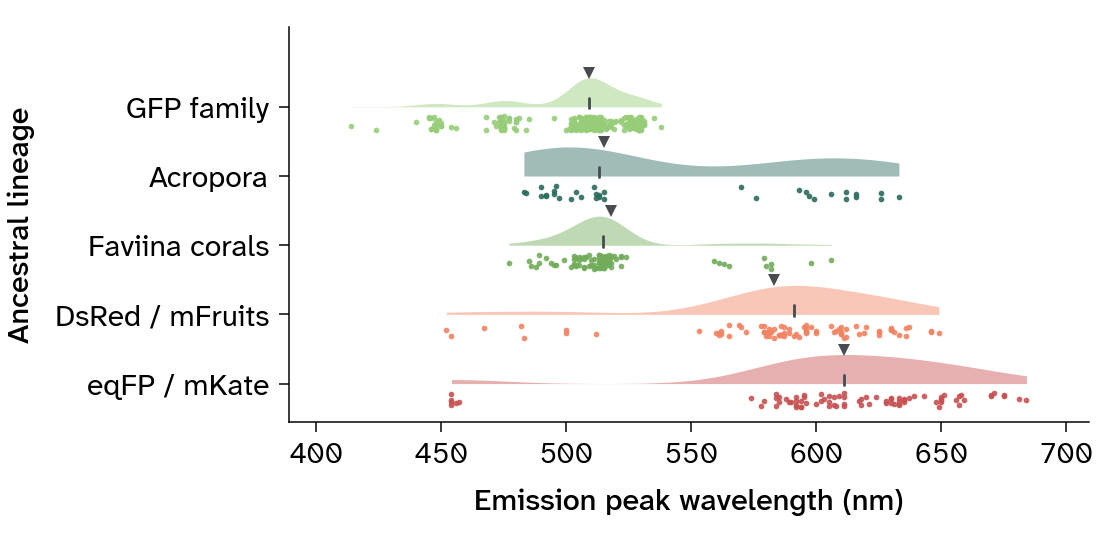

In [11]:
# One row per lineage: clipped density above the baseline, members as dots below, median as a tick are
# read the same way. Two departures: the violin and its dots take the lineage's own
# ancestral-emission colour from the curation notebook's palette, since the lineage *is* the colour
# claim being made; and each row carries its founding wild-type's emission as a tick above the
# density, which is the wavelength that colour was chosen from.
lineages = [dict(f=f, n=int((family == f).sum()), v=em[family == f], color=str(ANCESTOR[f][2]),
                 founder=ANCESTOR[f][0], founder_em=ANCESTOR[f][1])
            for f in sorted(big_fams, key=lambda f: np.median(em[family == f]))]

FIG_W, FIG_H = FULL_WIDE * 5 / 9, FULL_WIDE * 5 / 18

fig, ax = plt.subplots(figsize=(FIG_W * PX, FIG_H * PX))
fig.subplots_adjust(left=0.26, right=0.98, bottom=0.24, top=0.95)

jitter = np.random.default_rng(RNG_SEED)
for i, d in enumerate(lineages):
    v, y = d["v"], len(lineages) - 1 - i
    grid = np.linspace(v.min(), v.max(), 256)          # clipped, as in Figure 2
    dens = gaussian_kde(v)(grid)
    ax.fill_between(grid, y, y + VIOLIN_H * dens / dens.max(), color=d["color"], lw=0, alpha=0.45,
                    zorder=1)
    ax.scatter(v, y - 0.14 - DOT_BAND * jitter.random(d["n"]), s=8, color=d["color"], alpha=0.9,
               lw=0, zorder=3)
    ax.plot([np.median(v)] * 2, [y - 0.02, y + 0.13], color=str(apc.charcoal), lw=1.4, zorder=4)
    ax.plot([d["founder_em"]], [y + VIOLIN_H + 0.07], marker="v", ms=6, lw=0,
            color=str(apc.charcoal), zorder=4)
#     ax.annotate(f"{d['n']}", xy=(1.0, y), xycoords=("axes fraction", "data"), xytext=(6, -1),
#                 textcoords="offset points", ha="left", va="center", **NUMBER_NOTE)

ax.set_yticks(range(len(lineages)))
ax.set_yticklabels([SHORT[d["f"]] for d in lineages][::-1])
ax.set(xlim=EMLIM, ylim=(-0.55, len(lineages) + 0.15),      # EMLIM: Figure 2's limits, reused
       xlabel="Emission peak wavelength (nm)", ylabel="Ancestral lineage")
apc.mpl.style_plot(ax, monospaced_axes="x")
# ax.annotate("n", xy=(1.0, 1.0), xycoords="axes fraction", xytext=(6, 4),
#             textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
# The marker is named once, beside the top row's, rather than in a legend.
# ax.annotate("founding wild-type", xy=(lineages[0]["founder_em"], len(lineages) - 1 + VIOLIN_H + 0.07),
#             xycoords="data", xytext=(9, 0), textcoords="offset points", ha="left", va="center",
#             **ANNOTATION)

fig.savefig(f"{FIGDIR}/landscape_lineage_emission.svg")
fig.savefig(f"{FIGDIR}/landscape_lineage_emission.png", dpi=200)
plt.show()

**Figure 2. Within an ancestral family, emission still runs across most of the visible range.**
Emission peak of the 571 curated proteins in the five lineages with more than 30 members — one row
per group, a kernel density clipped to that group's own extremes, every member as a dot below it,
the median as a tick. Lineage assignment is the `parent_organism` regex of
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb), and
each row takes the Arcadia colour that notebook assigns it: the colour nearest what its founding
wild-type emits. Those founders are marked above each density (avGFP 509 nm, atenFP 515, Kaede 518,
DsRed 583, eqFP611 611); ordering rows by median emission happens to reproduce the founder ordering
exactly. The two catch-all groups are excluded (*other*, 103 proteins; *synthetic / unassigned*,
32), as are the four genuine but small lineages below 30 members (*Clavularia* 17, StayGold 16,
LanYFP 12, *Zoanthus* 7 — 52 proteins in total); the *Flavin-based* and *bacteriophytochrome* rules
match nothing here, since the pipeline's cofactor rule already removed those proteins.

Each lineage does sit near its founder, but its full range says how little that settles. Reading down
the rows: the GFP family's median emission is 509 nm over a 414-538 nm range (124 nm wide), *Acropora* /
*Montipora* 513 nm over 483-633 (150 nm), the Faviina corals 514.5 nm over 477-606 (129 nm), DsRed /
mFruits 591 nm over 452-649 (197 nm), and eqFP / mKate 611 nm over 454-684 (230 nm). The medians do
order themselves sensibly — the three green-founded ones span 5.5 nm in total, then a 77 nm step reaches
the two red lineages — but not one of them sits in a range narrower than 124 nm, and the green trio
overlaps almost completely: 77% of the GFP family and 79% of the Faviina corals fall in the same
500-530 nm window. The extremes are where protein engineering shows. *Entacmaea* runs from
Electra1/Bluebonnet2 at 454 nm to mNeptune684 at 684 nm, a 230 nm span within one ancestral family;
*Discosoma* covers 452 nm (mBlueberry1) to 649 nm (mPlum); and 41% of the *Acropora* / *Montipora*
proteins sit more than 50 nm from atenFP's 515 nm, which is what splits that row's density in two. Only
the GFP family is bounded on one side, stopping at 538 nm — no *Aequorea* protein in the set emits
orange or red.

Ancestry sets an expectation, not a colour. On these 571 proteins the within-lineage SD is 33.8 nm
against 53.6 nm overall, so the lineage labels absorb only about a third of the spread. As a
predictor the grouping is weak: assigning every protein its lineage mean gives an in-sample MAE of
22.1 nm against 44.3 nm for a single global mean — and against 13.3 nm and 10.9 nm for the surrogate
and oracle on proteins they have never seen (Figures 6 and 7). Ancestry sets the expectation; the
residues inside the family decide the colour.


## 3. The nested split

Figure 4 and Figure 5 each rank a 48-architecture sweep, but the two sweeps don't share a split.
Unlike [`../dataset_pipeline/make_dual_split.py`](../dataset_pipeline/make_dual_split.py)'s
coordinated design — where the **surrogate** split is primary and the oracle is carved out to
guarantee every protein trains at least one of the two models — this experiment's own
[`make_dual_split.py`](0_data_split/make_dual_split.py) makes the **oracle** split primary instead: 80/10/10 over
all 758 curated proteins, naive random (no clustering, no fixed pins). The surrogate's data is then
carved *only* from the oracle's training pool (606 proteins), so every surrogate protein is nested
inside oracle-train by construction.

Within those 606 the surrogate uses an **85/15 train/test split** — 515 proteins to fit and select
on, 91 held out — and does all of its model selection by **3-fold cross-validation inside the 515**
(`KFold(3, shuffle=True, random_state=0)`, so each config is fitted on ~343 proteins and scored on
the ~172 left out, three times). The 91-protein test set is touched once, at the very end
(Figure 6). `dual_splits.csv` still records that 515 as `train` 424 + `val` 91, the internal
partition the raw single-split sweep used before the CV pass pooled them; the pool and the 85/15
figure below are the same 515 proteins either way.

The net effect is the opposite of the source design. Rather than guaranteeing every protein trains
something, the oracle's own held-out proteins (152 of 758, its val + test) are excluded from the
surrogate entirely — those 152 are never seen by either model.

In [12]:
from sklearn.model_selection import KFold

N_FOLDS, FOLD_SEED = 3, 0        # the folds cv_all_surrogate.py actually uses

dual = pd.read_csv(DUAL_SPLITS).sort_values("index").reset_index(drop=True)
# dual_splits.csv and peaks_assignments.csv are both built off the same curated index, so a
# straight row check is enough to confirm dual lines up with curated (and so with x, y, ex, em).
assert len(dual) == len(curated), "dual_splits.csv should cover exactly the curated set"
assert (dual.name.to_numpy() == curated.name.to_numpy()).all(), "row order must match curated/x/y"

SURR_ORDER = ["train", "val", "test", "excluded"]
ORACLE_ORDER = ["train", "val", "test"]
ctab = pd.crosstab(dual.surrogate_role, dual.oracle_role).reindex(
    index=SURR_ORDER, columns=ORACLE_ORDER, fill_value=0)
print(ctab)
print()
print("surrogate roles as recorded:", dual.surrogate_role.value_counts().reindex(SURR_ORDER).to_dict())
print("oracle roles:               ", dual.oracle_role.value_counts().reindex(ORACLE_ORDER).to_dict())

# The deployed surrogate protocol: the recorded train+val is one 85% pool that CV subdivides, so
# read the file that way rather than as three fixed roles.
n_pool = int(dual.surrogate_role.isin(["train", "val"]).sum())
n_test = int((dual.surrogate_role == "test").sum())
n_avail = n_pool + n_test
otot = ctab.sum(axis=0)          # per oracle role, across ALL surrogate rows (incl. excluded)
folds = list(KFold(n_splits=N_FOLDS, shuffle=True, random_state=FOLD_SEED).split(np.arange(n_pool)))

print(f"\nsurrogate: {n_avail} available (all nested in oracle-train) -> "
      f"{n_pool} train ({n_pool / n_avail:.0%}) / {n_test} test ({n_test / n_avail:.0%})")
for i, (fit, held) in enumerate(folds, 1):
    print(f"  fold {i}: fit {len(fit)}, held out {len(held)}")
print(f"held out from both models entirely: {(dual.surrogate_role == 'excluded').mean():.0%} of the "
      f"{len(dual)} proteins (the oracle's own val+test, which the surrogate never sees)")

oracle_role     train  val  test
surrogate_role                  
train             424    0     0
val                91    0     0
test               91    0     0
excluded            0   76    76

surrogate roles as recorded: {'train': 424, 'val': 91, 'test': 91, 'excluded': 152}
oracle roles:                {'train': 606, 'val': 76, 'test': 76}

surrogate: 606 available (all nested in oracle-train) -> 515 train (85%) / 91 test (15%)
  fold 1: fit 343, held out 172
  fold 2: fit 343, held out 172
  fold 3: fit 344, held out 171
held out from both models entirely: 20% of the 758 proteins (the oracle's own val+test, which the surrogate never sees)


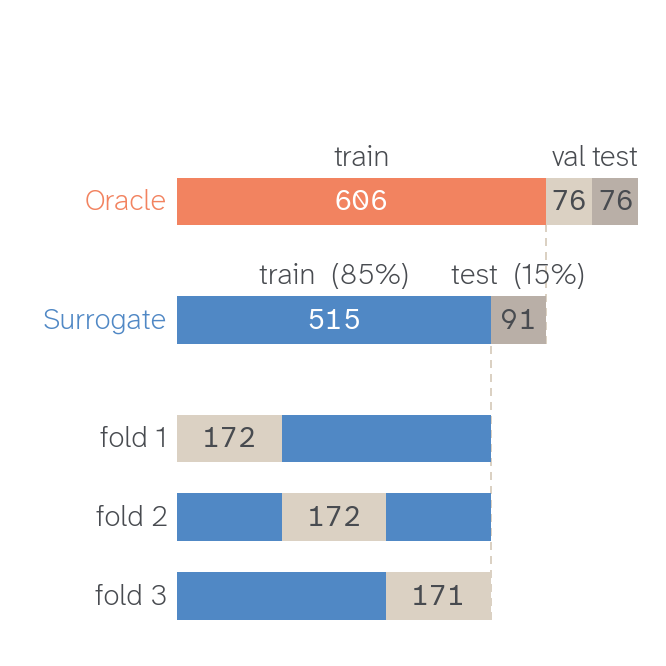

In [13]:
# Nested bars on one shared x-axis of proteins: each row's universe is the coloured block of the row
# above it, so the nesting is read off the alignment rather than drawn as a separate diagram. Colour
# means "fitted on", the two neutrals mean held out -- taupe for a selection hold-out (oracle val,
# each fold's third) and grey for a final test set that is touched once.
BAR_H = 0.60
Y_OR, Y_SU = 5.0, 3.5             # oracle and surrogate rows; the folds sit at 2, 1, 0
n_or = {r: int(otot[r]) for r in ORACLE_ORDER}

FIG_W, FIG_H = FULL_WIDE * 1 / 3, FULL_WIDE * 1 / 3

fig, ax = plt.subplots(figsize=(FIG_W * PX, FIG_H * PX))
fig.subplots_adjust(left=0.115, right=0.985, bottom=0.04, top=0.88)


def block(x0, w, y, color, inside=None, above=None):
    """One segment of a row: count inside the block, role name above it."""
    ax.barh([y], [w], left=x0, height=BAR_H, color=color, ec="none", zorder=2)
    if inside:
        ax.text(x0 + w / 2, y, inside, ha="center", va="center", zorder=3,
                **{**NUMBER_NOTE,
                   "color": "white" if color in (HIGHLIGHT, CONTRAST) else str(apc.charcoal)})
    if above:
        ax.text(x0 + w / 2, y + BAR_H / 2 + 0.10, above, ha="center", va="bottom", **ANNOTATION)


# Guides for the two nestings: the surrogate's universe is oracle-train, the folds' is surrogate-train.
ax.plot([n_or["train"]] * 2, [Y_SU - BAR_H / 2, Y_OR - BAR_H / 2], color=NEUTRAL_SOFT, lw=1.0,
        ls=(0, (4, 3)), zorder=0)
ax.plot([n_pool] * 2, [-BAR_H / 2, Y_SU - BAR_H / 2], color=NEUTRAL_SOFT, lw=1.0, ls=(0, (4, 3)),
        zorder=0)

block(0, n_or["train"], Y_OR, CONTRAST, inside=f"{n_or['train']}", above="train")
block(n_or["train"], n_or["val"], Y_OR, NEUTRAL_SOFT, inside=f"{n_or['val']}", above="val")
block(n_or["train"] + n_or["val"], n_or["test"], Y_OR, NEUTRAL, inside=f"{n_or['test']}", above="test")
ax.text(-16, Y_OR, "Oracle", ha="right", va="center", **{**ANNOTATION, "color": CONTRAST})

block(0, n_pool, Y_SU, HIGHLIGHT, inside=f"{n_pool}", above=f"train  ({n_pool / n_avail:.0%})")
block(n_pool, n_test, Y_SU, NEUTRAL, inside=f"{n_test}", above=f"test  ({n_test / n_avail:.0%})")
ax.text(-16, Y_SU, "Surrogate", ha="right", va="center", **{**ANNOTATION, "color": HIGHLIGHT})

# Fold blocks are drawn contiguous for legibility; the real KFold(shuffle=True) folds are random
# thirds of the pool, which as a barcode reads as noise rather than as "one third held out".
edges = np.linspace(0, n_pool, N_FOLDS + 1).round().astype(int)
for i, (fit, held) in enumerate(folds):
    y, lo, hi = N_FOLDS - 1 - i, edges[i], edges[i + 1]
    block(0, n_pool, y, HIGHLIGHT)
    block(lo, hi - lo, y, NEUTRAL_SOFT, inside=f"{len(held)}")
    ax.text(-16, y, f"fold {i + 1}", ha="right", va="center", **ANNOTATION)

ax.set_xlim(-165, len(dual) + 30)
ax.set_ylim(-0.55, Y_OR + 1.55)
ax.axis("off")

fig.savefig(f"{FIGDIR}/dual_split_overview.svg")
fig.savefig(f"{FIGDIR}/dual_split_overview.png", dpi=200)
plt.show()

**Figure 3. The surrogate's data is nested inside the oracle's training pool, split 85/15, and
cross-validated three ways inside the 85.** Every row is drawn on the same axis of curated proteins,
so each row's universe is the coloured block of the row above it. **Oracle:** a naive-random 80/10/10
over all 758 — train 606, val 76, test 76. **Surrogate:** carved only from those 606, and split 85/15
into a 515-protein pool and a 91-protein test set. **Folds:** `KFold(3, shuffle=True,
random_state=0)` within the 515, so each of Figure 4's 48 configurations is fitted three times on
343-344 proteins and scored on the 171-172 left out. Fold blocks are drawn as contiguous thirds for
legibility — the actual folds are random thirds of the pool. Colour means fitted on; the two neutrals
mean held out, taupe for a selection hold-out (the oracle's val, each fold's third) and grey for a
test set touched once at the end (Figures 6 and 7).

The nesting has a consequence worth stating plainly: the surrogate row stops where the oracle's train
block stops, so the 152 proteins in the oracle's own val + test (20% of the curated set) are seen by
**neither** model. That is the opposite of
[`../dataset_pipeline/make_dual_split.py`](../dataset_pipeline/make_dual_split.py)'s coordinated
design, where the surrogate split is primary and the oracle is carved out so that every protein
trains at least one of the two. Both splits here are random and unclustered, with no proteins pinned
to fixed roles.

One bookkeeping note: `dual_splits.csv` records the 515 as two roles, `train` 424 and `val` 91,
because the first pass over the 48 architectures was a single-split sweep that used exactly that
partition. Cross-validation pools them, and every number quoted from Figure 4 onward is on the pooled
515 — so the file's three surrogate roles and this figure's two describe the same proteins.

## 4. Architecture sweep for the surrogate peak model

The surrogate that guides generation is chosen from the same 48-architecture grid as the source
pipeline: three backbones (`mlp` pool-only, `cnn`, `transformer`) crossed with pooling readouts
`mean`, `max`, `concat`, `concatstd`, `attn`, plus the covariance-probe pool `cov`
($z_i = W^\top x_i$, then $C_z = \tfrac{1}{L}\sum_i z_i z_i^\top$, flattened over its upper
triangle) at CNN depth 1-3, and, for `cnn`/`transformer`, depth 1-4. Every configuration is trained
once (seed 0) on the ESM-2 embedding of an internal 424/91 train/val partition of Figure 3's
515-protein pool, with the same 91-protein test set held out, and scored by validation MAE, averaged over excitation and emission — see
[`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py).

That single-split ranking is noisy over only 91 validation proteins, so before committing to a
config it is re-run through 3-fold cross-validation on the pooled train+val (515 proteins,
[`cv_all_surrogate.py`](1_surrogate_oracle_training/cv_all_surrogate.py)), refitting each of the 48 configs three times on
random folds with a fixed 91-row test held out throughout as a common yardstick. **This figure is
that cross-validated ranking, not the raw single-split sweep** — the two disagree on the winner
(see the caption below).

An embedding-nearest-neighbour baseline is pinned alongside the ranking: predict a held-out
protein's peak as the mean peak of its *k* nearest training proteins in mean-pooled ESM-2 space
(cosine distance, *k* = 1, 3, 5, 10, 20). It is run through the **same three folds** as the configs
— same pool, same `KFold(3, shuffle=True, random_state=0)`, so the same proteins are held out — and
carries the same fold-to-fold error bars. That matters because a null fitted on the full 424-row
train split is not comparable to configs fitted on 343: retrieval baselines gain directly with the
number of proteins available to retrieve from, and the earlier single-split version of this figure
(20.0 nm at *k* = 1) flattered the null by ~5 nm for that reason alone.

In [14]:
import glob
import re

import torch

BACKBONE_LABEL = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
SURR_DIR = "trained_models/surrogate_sweep"
CV_CSV = "trained_models/surrogate_cv3.csv"


def load_surrogate_sweep(out_dir):
    """One row per checkpoint: architecture/pooling/depth and its (single-split) validation MAE (nm)."""
    recs = []
    for p in sorted(glob.glob(f"{out_dir}/*.pt")):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        recs.append(dict(
            arch=ck["arch"], pool=ck["pool"], depth=ck["depth"],
            label=f"{BACKBONE_LABEL[ck['arch']]} ({ck['depth']}) - {ck['pool']}",
            val_mae=ck["val_mae"], test_mae=ck["test_mae"],
        ))
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


def load_surrogate_cv(csv_path):
    """One row per config: architecture/pooling/depth and its 3-fold CV fold-val / fixed-test MAE
    (nm, mean +/- SD across folds) -- this is the ranking that actually picked the surrogate.
    """
    cv = pd.read_csv(csv_path)
    recs = []
    for label, g in cv.groupby("label"):
        arch, pool, depth = re.match(r"([a-z]+)-([a-z]+)-d(\d+)", label).groups()
        recs.append(dict(
            arch=arch, pool=pool, depth=int(depth),
            label=f"{BACKBONE_LABEL[arch]} ({depth}) - {pool}",
            val_mae=g.fold_va_mae.mean(), val_std=g.fold_va_mae.std(),
            test_mae=g.fixed_test_mae.mean(), test_std=g.fixed_test_mae.std(),
        ))
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


sweep = load_surrogate_cv(CV_CSV)
best, worst = sweep.iloc[0], sweep.iloc[-1]
print(f"{len(sweep)} configs (3-fold CV) | best {best['label']} at {best.val_mae:.1f} +/- "
      f"{best.val_std:.1f} nm fold-val ({best.test_mae:.1f} +/- {best.test_std:.1f} nm fixed-test) | "
      f"worst {worst['label']} at {worst.val_mae:.1f} nm")

raw_sweep = load_surrogate_sweep(SURR_DIR)          # single-split sweep, for contrast only
raw_best = raw_sweep.iloc[0]
cv_rank_of_raw_best = int(sweep.index[sweep.label == raw_best["label"]][0]) + 1
print(f"raw single-split sweep top pick: {raw_best['label']} at {raw_best.val_mae:.1f} nm val "
      f"-- ranks {cv_rank_of_raw_best} of {len(sweep)} once cross-validated")

48 configs (3-fold CV) | best CNN (1) - max at 15.3 +/- 1.4 nm fold-val (18.8 +/- 2.2 nm fixed-test) | worst CNN (3) - cov at 27.5 nm


raw single-split sweep top pick: CNN (2) - concat at 11.4 nm val -- ranks 3 of 48 once cross-validated


In [15]:
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

K_SWEEP = [1, 3, 5, 10, 20]
N_FOLDS, FOLD_SEED = 3, 0          # identical to cv_all_surrogate.py / cv_surrogate_top5.py


def surrogate_nn_baseline(ks=K_SWEEP):
    """Embedding-NN null: predict a held-out peak as the mean peak of its k nearest training
    proteins in mean-pooled ESM-2 space -- the same per-residue cache the sweep trains on, pooled
    the simple way rather than learned.

    Run through the SAME 3-fold partition as the configs it is plotted against: pool =
    concat(train, val) in that exact order, KFold(3, shuffle=True, random_state=0), neighbours
    fitted on each fold's ~343 training rows and scored on its ~172 held-out rows. Since KFold
    shuffles by position and the pool array is built the same way here as in cv_all_surrogate.py,
    the folds contain the same proteins -- so the null bars and the config bars are answering the
    question on identical data, not merely on comparable protocols.

    A k-NN has no epochs, so unlike the configs it gets no early-stopping pick on its own held-out
    fold; that asymmetry favours the configs and is worth remembering when reading the margin.
    Returns {label: (mean, SD)} over folds, plus the single-split value for continuity with the
    earlier version of this figure.
    """
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/esm_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/esm_residue_len.npy").astype(int)
    role = (pd.read_csv(DUAL_SPLITS)
            .sort_values("index").set_index("index")["surrogate_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]
    pool = np.concatenate([tr, va])

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])

    def nn_mae(fit_idx, eval_idx, k):
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[fit_idx])
        pred = peaks[fit_idx][nn.kneighbors(X[eval_idx], return_distance=False)].mean(axis=1)
        return float(np.abs(pred - peaks[eval_idx]).mean())

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=FOLD_SEED)
    folds = list(kf.split(pool))
    cv, single = {}, {}
    for k in ks:
        per_fold = [nn_mae(pool[tri], pool[vai], k) for tri, vai in folds]
        cv[f"NN k={k}"] = (float(np.mean(per_fold)), float(np.std(per_fold, ddof=1)))
        single[f"NN k={k}"] = nn_mae(tr, va, k)          # fixed 70/15/15, the old comparison
    return cv, single


nulls, nulls_single = surrogate_nn_baseline()
best_null = min(m for m, _ in nulls.values())
worst_null = max(m for m, _ in nulls.values())
n_below_best_null = int((sweep.val_mae > best_null).sum())
n_below_worst_null = int((sweep.val_mae > worst_null).sum())
for k, (m, s) in nulls.items():
    print(f"{k:8} {m:5.1f} +/- {s:4.1f} nm  (fixed 70/15/15: {nulls_single[k]:5.1f} nm)")
print(f"best null {best_null:.1f} nm vs winner {sweep.val_mae.min():.1f} nm "
      f"-- margin {best_null - sweep.val_mae.min():.1f} nm")
print(f"{n_below_best_null} of {len(sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")


NN k=1    24.7 +/-  3.2 nm  (fixed 70/15/15:  20.0 nm)
NN k=3    25.7 +/-  1.2 nm  (fixed 70/15/15:  20.5 nm)
NN k=5    25.8 +/-  2.4 nm  (fixed 70/15/15:  21.7 nm)
NN k=10   27.5 +/-  2.4 nm  (fixed 70/15/15:  21.9 nm)
NN k=20   29.2 +/-  2.0 nm  (fixed 70/15/15:  23.5 nm)
best null 24.7 nm vs winner 15.3 nm -- margin 9.3 nm
7 of 48 configs are worse than the best null; 0 are worse than every null


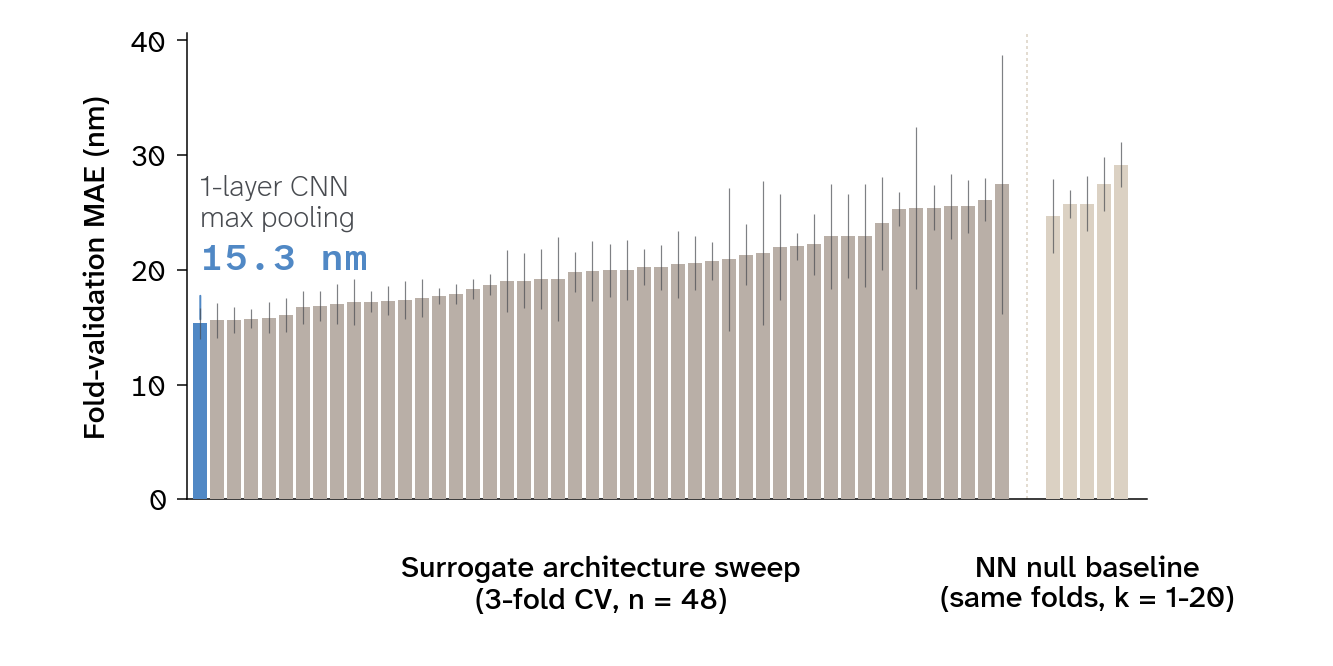

In [16]:
# Best config in HIGHLIGHT; everything else -- other configs and null baselines alike -- recedes
# into neutral tones, per the guide's "one series emphasized, the rest recede" pattern. Error bars
# (fold-to-fold SD) are new here versus the single-split version of this figure, since that spread
# is the whole reason a CV pass was run in the first place.
ranked = sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
null_items = [(lab, m, s) for lab, (m, s) in nulls.items()]   # (label, mean, fold SD)
best = ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(ranked))
x_null = np.arange(len(null_items)) + len(ranked) + GAP
bar_color = [HIGHLIGHT if i == 0 else NEUTRAL for i in range(len(ranked))]

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.95, bottom=0.25)

ax.bar(x_cfg, ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.errorbar(x_cfg, ranked["val_mae"], yerr=ranked["val_std"], fmt="none",
            ecolor=str(apc.charcoal), elinewidth=0.6, capsize=1.5, zorder=4, alpha=0.7)
ax.bar(x_null, [m for _, m, _ in null_items], color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
# Same fold-to-fold error bars as the configs -- the null is now run through the same 3 folds,
# so it earns the same uncertainty mark rather than reading as a single exact number.
ax.errorbar(x_null, [m for _, m, _ in null_items], yerr=[s for _, _, s in null_items], fmt="none",
            ecolor=str(apc.charcoal), elinewidth=0.6, capsize=1.5, zorder=4, alpha=0.7)
ax.axvline(len(ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Individual configs are no longer the point -- only the winner is labelled, with a leader line
# and its exact fold-validation MAE set in the guide's mono numerals, SemiBold for emphasis.
best_text = f"{best.depth}-layer {BACKBONE_LABEL[best.arch]}\n{best['pool']} pooling"
ax.annotate(best_text, xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{best.val_mae:.1f} nm", xy=(0, best.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": HIGHLIGHT})
ax.annotate("", xy=(0, best.val_mae), xytext=(0, best.val_mae + ranked["val_mae"].max() * 0.10),
            arrowprops=dict(arrowstyle="-", color=HIGHLIGHT, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)          # headroom so the null label clears the last bar
ax.set_ylim(0, max((ranked["val_mae"] + ranked["val_std"]).max(),
                   max(m + s for _, m, s in null_items)) * 1.05)
ax.set_ylabel("Fold-validation MAE (nm)")

# No legend -- each group is labelled in place, centred under its own bars, rather than decoded
# through a key. Blended transform: x in data coordinates, y in axes fraction (below the spines).
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Surrogate architecture sweep\n(3-fold CV, n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(same folds, k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_cv_mae.svg")
fig.savefig(f"{FIGDIR}/peak_surrogate_sweep_cv_mae.png", dpi=200)
plt.show()

**Figure 4. Three-fold cross-validation, not the single 70/15/15 split, is what actually confirms
CNN (1) - max as the surrogate -- and on matched folds it clears the strongest null baseline by
9.4 nm.** Mean fold-validation MAE (nm, ± 1 SD across 3 folds, averaged over excitation and
emission) for all 48 backbone x pooling x depth configurations, each refit three times
([`cv_all_surrogate.py`](1_surrogate_oracle_training/cv_all_surrogate.py)) on random 3-fold splits of the surrogate train+val
pool (515 proteins), ranked against an embedding-nearest-neighbour null (cosine distance over
mean-pooled ESM-2, *k* = 1, 3, 5, 10, 20) run through **those same three folds**, with the same
fold-to-fold error bars. The winner is called out in Aegean.

On the raw single-split sweep ([`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py), the same protocol
run once with no folds) CNN (1) - max actually ranks 4th, marginally behind CNN (2) - concat (11.4
vs 11.7 nm val) — a gap well inside the noise of one 91-protein validation set. Cross-validation
settles it: CNN (1) - max has both the lowest mean fold-validation MAE (15.3 ± 1.4 nm) and the
lowest fixed-test MAE (18.8 ± 2.2 nm, on the 91-row test set every fold shares) of all 48
configurations. Seven of the 48 fail to clear the strongest null (*k* = 1, 24.7 ± 3.2 nm) and none
falls behind every null tested.

Matching the folds costs the null about 5 nm and is the honest way to run it: on the fixed 70/15/15
split the same *k* = 1 null reads 20.0 nm, but there it retrieves from all 424 training proteins
while every cross-validated config was fitted on a fold's 343. Retrieval baselines gain directly
with the number of proteins available to match against, so the earlier version of this figure was
comparing across a data-size difference rather than across methods. Two asymmetries remain in the
configs' favour and are worth reading the 9.4 nm margin against: each config gets to pick its best
epoch on the very fold it is scored on, which a *k*-NN has no analogue for, and *k* = 1 was chosen
after seeing all five values (it wins on every fold, so this changes nothing).

Depth and pooling interact the way the raw sweep already suggested: CNNs hold their edge shallow
(mean fold-va MAE 17.0 and 17.7 nm at depth 1-2) and degrade from depth 3 (20.1, 20.7 nm);
transformers are flatter through depth 2 (18.7, 18.6 nm) before falling off from depth 3 (21.4 nm)
and further at depth 4 (24.6 nm). The covariance-probe pool is competitive at CNN depth 1-2 but its
depth-3 variant isn't just worse, it's unstable: CNN (3) - cov is both the single worst
configuration in the grid (27.5 nm) and by far the least reproducible across folds (± 11.3 nm) —
the same depth-3 breakdown Figure 5 flags on the oracle sweep, more severe there.

## 5. Architecture sweep for the oracle peak model

The oracle evaluates designs independently of the surrogate: the same backbone x pooling x depth
sweep and protocol, but on a ProstT5 encoder embedding (structure-aware, 1024-d) and this
experiment's own oracle-role split (606/76/76 train/val/test), so it differs from the surrogate in
both the pretrained language model and the split it is scored against, not just the trained
readout. Sweep code lives in the same [`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py) as Figure 4;
this is that sweep's ranking, in the same style, so the two can be compared directly. Unlike the
surrogate, the oracle here is scored on the raw single-split sweep — no CV pass was run for it in
this experiment.

As in Figure 4, an embedding-nearest-neighbour null is pinned separately: predict a validation
protein's peak as the mean peak of its *k* nearest training proteins in mean-pooled ProstT5 space
(cosine distance, *k* = 1, 3, 5, 10, 20).

In [17]:
ORACLE_DIR = "trained_models/oracle_sweep"

# load_surrogate_sweep is generic despite the name -- any checkpoint dir with the same fields.
oracle_sweep = load_surrogate_sweep(ORACLE_DIR)
oracle_best, oracle_worst = oracle_sweep.iloc[0], oracle_sweep.iloc[-1]
print(f"{len(oracle_sweep)} configs | best {oracle_best['label']} at {oracle_best.val_mae:.1f} nm val "
      f"({oracle_best.test_mae:.1f} nm test) | worst {oracle_worst['label']} at {oracle_worst.val_mae:.1f} nm")

48 configs | best CNN (1) - max at 8.7 nm val (12.3 nm test) | worst CNN (3) - cov at 37.4 nm


In [18]:
def oracle_nn_baseline(ks=K_SWEEP):
    """Same embedding-NN null as Figure 4, on the oracle's ProstT5 cache and split -- but on the
    single 80/10/10 split rather than folds, because the ORACLE was itself selected that way (no CV
    was run for it). Each side of this figure therefore uses one train fit and one validation
    score, so the null and the configs stay protocol-matched here too.
    """
    peaks = np.load(f"{CURATED}/peaks.npy").astype(np.float32)
    H = np.load(f"{CURATED}/prostt5_residue_fp16.npy")
    Ls = np.load(f"{CURATED}/prostt5_residue_len.npy").astype(int)
    role = (pd.read_csv(DUAL_SPLITS)
            .sort_values("index").set_index("index")["oracle_role"].to_numpy())
    tr, va = np.where(role == "train")[0], np.where(role == "val")[0]

    X = np.stack([H[i, :Ls[i]].astype(np.float32).mean(0) for i in range(len(H))])
    out = {}
    for k in ks:
        nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
        neighbours = nn.kneighbors(X[va], return_distance=False)
        pred = peaks[tr][neighbours].mean(axis=1)
        out[f"NN k={k}"] = float(np.abs(pred - peaks[va]).mean())
    return out


oracle_nulls = oracle_nn_baseline()
n_below_best_null = int((oracle_sweep.val_mae > min(oracle_nulls.values())).sum())
n_below_worst_null = int((oracle_sweep.val_mae > max(oracle_nulls.values())).sum())
for k, v in oracle_nulls.items():
    print(f"{k:8} {v:5.1f} nm")
print(f"{n_below_best_null} of {len(oracle_sweep)} configs are worse than the best null; "
      f"{n_below_worst_null} are worse than every null")

NN k=1    16.7 nm
NN k=3    18.9 nm
NN k=5    18.0 nm
NN k=10   21.8 nm
NN k=20   23.3 nm
6 of 48 configs are worse than the best null; 1 are worse than every null


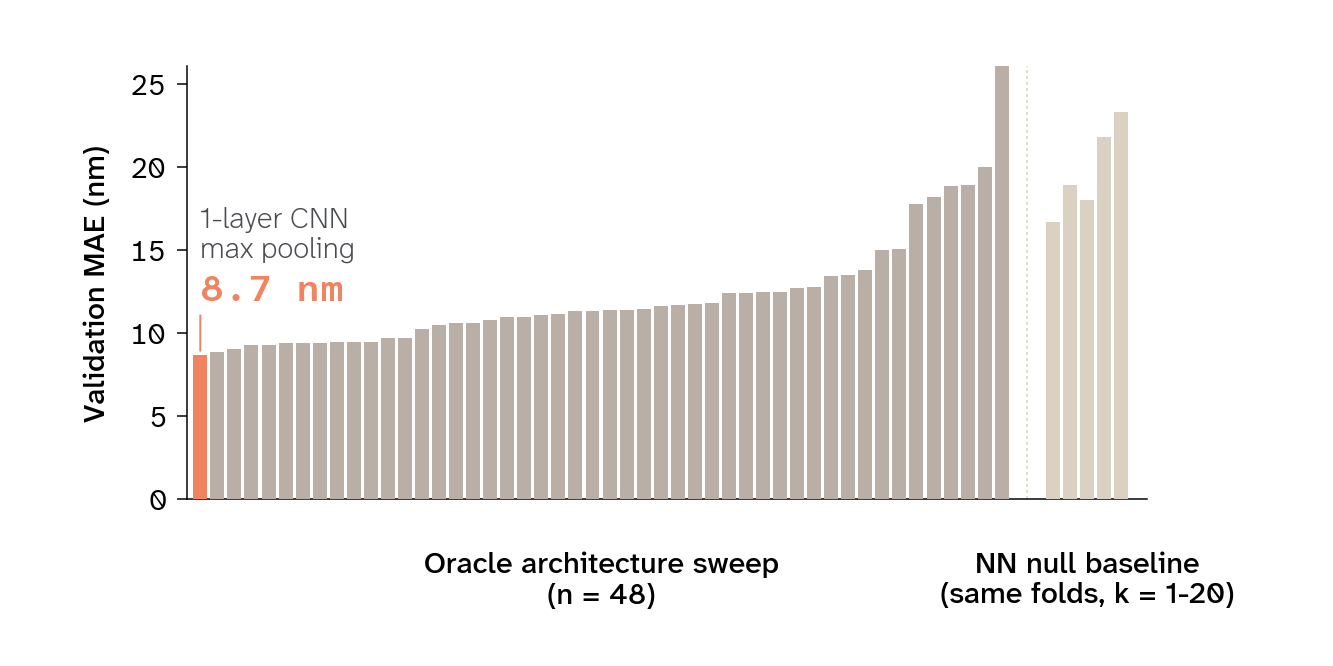

In [19]:
# Same design as Figure 4, but the winner is called out in CONTRAST (orange) rather than
# HIGHLIGHT, so the two sweep figures read as a pair with a distinct colour per model. CNN (3) -
# cov is such a severe outlier (37 nm, versus a 20 nm runner-up) that it would compress the other
# 47 bars into a sliver if the axis stretched to fit it, so the axis is capped near the runner-up
# and that one bar is simply clipped -- still present in the chart, just cut off at the top, with
# no callout text on it.
oracle_ranked = oracle_sweep.sort_values("val_mae", ascending=True).reset_index(drop=True)
oracle_null_items = list(oracle_nulls.items())
oracle_best_row = oracle_ranked.iloc[0]
GAP = 2.0
x_cfg = np.arange(len(oracle_ranked))
x_null = np.arange(len(oracle_null_items)) + len(oracle_ranked) + GAP
bar_color = [CONTRAST if i == 0 else NEUTRAL for i in range(len(oracle_ranked))]

ylim_max = max(oracle_ranked["val_mae"].iloc[:-1].max(),
               max(v for _, v in oracle_null_items)) * 1.12

fig, ax = plt.subplots(figsize=(2 / 3 * FULL_WIDE * PX, 1 / 3 * FULL_WIDE * PX))
fig.subplots_adjust(left=0.14, right=0.86, top=0.9, bottom=0.25)

ax.bar(x_cfg, oracle_ranked["val_mae"], color=bar_color, width=0.82, edgecolor="none", zorder=3)
ax.bar(x_null, [v for _, v in oracle_null_items], color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
ax.axvline(len(oracle_ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# Only the winner is labelled, with a leader line and its exact validation MAE set in the guide's
# mono numerals, SemiBold for emphasis.
best_text = f"{oracle_best_row.depth}-layer {BACKBONE_LABEL[oracle_best_row.arch]}\n{oracle_best_row['pool']} pooling"
ax.annotate(best_text, xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 46), textcoords="offset points", ha="left", va="bottom", **ANNOTATION)
ax.annotate(f"{oracle_best_row.val_mae:.1f} nm", xy=(0, oracle_best_row.val_mae), xycoords="data",
            xytext=(0, 24), textcoords="offset points", ha="left", va="bottom",
            **{**NUMBER_NOTE, "fontsize": 19, "fontweight": "semibold", "color": CONTRAST})
ax.annotate("", xy=(0, oracle_best_row.val_mae),
            xytext=(0, oracle_best_row.val_mae + ylim_max * 0.10),
            arrowprops=dict(arrowstyle="-", color=CONTRAST, lw=1))

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.5)
ax.set_ylim(0, ylim_max)
ax.set_ylabel("Validation MAE (nm)")

label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
ax.text(x_cfg.mean(), -0.12, "Oracle architecture sweep\n(n = 48)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)
ax.text(x_null.mean(), -0.12, "NN null baseline\n(same folds, k = 1-20)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.svg")
fig.savefig(f"{FIGDIR}/peak_oracle_sweep_val_mae.png", dpi=200)
plt.show()

**Figure 5. The independently-scored oracle confirms the same winning architecture, CNN (1) -
max, and cuts its null baseline's error by a larger fraction than the surrogate does.** Validation MAE (nm,
averaged over excitation and emission) for the same 48-configuration sweep
([`sweep_peak_oracle.py`](1_surrogate_oracle_training/sweep_peak_oracle.py)), trained once (seed 0) on the ProstT5 embedding
and this experiment's own oracle-role split (606/76/76 train/val/test,
[`make_dual_split.py`](0_data_split/make_dual_split.py)), ranked against an embedding-nearest-neighbour null on
the same ProstT5 space (*k* = 1, 3, 5, 10, 20). CNN (1) - max is called out in Amber, pairing with
Figure 4's blue.

**CNN (3) - cov** is clipped off the top of the axis rather than plotted at scale: at 37.4 nm it is
almost double the next-worst configuration (**None (0) - mean**, the pool-only baseline, 20.0 nm)
and would compress the other 47 bars into a sliver if the axis stretched to fit it — the same
depth-3 covariance-probe breakdown Figure 4 flags as unstable on the surrogate, more severe here.
Set that one outlier aside and only 5 of 48 configurations fail to beat the strongest null (*k*=1,
16.7 nm), and nothing but the clipped outlier falls behind every null tested — a cleaner sweep than
the surrogate's. The right way to compare that across the two panels is relative, not absolute: the
oracle's winner cuts its null's error by 48% (8.7 vs 16.7 nm) against the surrogate's 38% (15.3 vs
24.7 nm). The absolute gaps — 8.0 nm here, 9.4 nm in Figure 4 — are not comparable, because the
oracle sweep and its null both fit on 606 proteins under one split while Figure 4's configs and
null both fit on a fold's 343.

Depth behaves differently on ProstT5 than on ESM-2: CNN performance is close through depth 1-2
(11.1, 10.4 nm) and, once the depth-3 outlier is set aside, stays in that same range through depth
4 (10.9, 11.6 nm) rather than degrading monotonically; transformers hold flat through depth 3
(11.2, 10.8, 10.9 nm) and only fall off at depth 4 (13.6 nm) — one depth later than the surrogate's
transformer cliff. Mean pooling still never reaches the top half of the ranking (best rank 19,
**TF (3) - mean** at 11.0 nm).

## 6. Test-set predictions: the deployed surrogate

Figure 4 ranked all 48 surrogate configs by 3-fold CV MAE — but the model actually used to guide
design isn't any one of those fold-models (each only trained on two-thirds of the pool). Once CNN
(1) - max was confirmed as the architecture, it was refit once more on the *full* train+val pool
(515 proteins, [`train_final_surrogate.py`](1_surrogate_oracle_training/train_final_surrogate.py)), with the epoch budget fixed
at 71 — the mean of the epoch each CV fold early-stopped at — since there is no held-out val left
to early-stop on once train and val are both used for fitting. This is that final, once-refit
model, run here on the 91-row test split it has never seen in any form. The oracle's equivalent is
Figure 7.

In [20]:
# experiment root + vendored lib on the import path (stage scripts live one level down)
import sys, os
for _p in ("", "lib", "msa", "1_surrogate_oracle_training"):
    _a = os.path.abspath(_p)
    if _a not in sys.path: sys.path.insert(0, _a)

import design_common as dc
import peak_models as pm
import sweep_peak_oracle as spo

dev = spo.device()


def predict_split(ckpt_path, D, idx):
    """Run a saved checkpoint over D's idx rows -> (n, 2) nm predictions."""
    base, ck = pm.load_model(ckpt_path, dev, out=2)
    net = pm.wrap(base, ck["mean"], ck["std"], dev)
    net.eval()
    ps = []
    with torch.no_grad():
        for Hb, mk, b in spo.base.batches(D, idx, dev):
            ps.append(net(Hb, mk).cpu().numpy())
    return np.concatenate(ps)


def col_metrics(p, t):
    """MAE (nm) / Pearson r / R2 / n for one true-vs-predicted column."""
    r2 = 1.0 - float(np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2))
    return dict(mae=float(np.abs(p - t).mean()), r=float(np.corrcoef(p, t)[0, 1]), r2=r2, n=len(t))


def test_metrics(role, ckpt_path):
    """Predictions on role's test split from the given checkpoint, plus MAE/r/R2/n pooled
    (ex_max and em_max together) and separately per peak.
    """
    D = spo.load_data(role, dev)
    base, ck = pm.load_model(ckpt_path, dev, out=2)
    label = f"{BACKBONE_LABEL[ck['arch']]} ({ck['depth']}) - {ck['pool']}"
    P = predict_split(ckpt_path, D, D["te"])
    T = D["Pk"].cpu().numpy()[D["te"]]
    return dict(P=P, T=T, label=label, pooled=col_metrics(P.ravel(), T.ravel()),
                ex=col_metrics(P[:, 0], T[:, 0]), em=col_metrics(P[:, 1], T[:, 1]))


# dc.SURR_CKPT/dc.ORAC_CKPT are the actual checkpoints design_common.py (and so
# design_knownstruct.py) load for this experiment's guided design -- not the raw sweep-selected
# files under trained_models/{surrogate,oracle}_sweep/.
surr_test = test_metrics("surrogate", str(dc.SURR_CKPT))
oracle_test = test_metrics("oracle", str(dc.ORAC_CKPT))

for name, m in [("surrogate", surr_test), ("oracle", oracle_test)]:
    print(f"{name} ({m['label']}):")
    for k, lab in [("pooled", "pooled (ex+em)"), ("ex", "excitation "), ("em", "emission  ")]:
        v = m[k]
        print(f"  {lab}  MAE={v['mae']:5.2f} nm  r={v['r']:.3f}  R2={v['r2']:.3f}  n={v['n']}")

surrogate (CNN (1) - max):
  pooled (ex+em)  MAE=17.55 nm  r=0.876  R2=0.756  n=182
  excitation   MAE=21.84 nm  r=0.818  R2=0.651  n=91
  emission    MAE=13.27 nm  r=0.914  R2=0.828  n=91
oracle (CNN (1) - max):
  pooled (ex+em)  MAE=12.27 nm  r=0.941  R2=0.880  n=152
  excitation   MAE=13.70 nm  r=0.933  R2=0.866  n=76
  emission    MAE=10.85 nm  r=0.939  R2=0.871  n=76


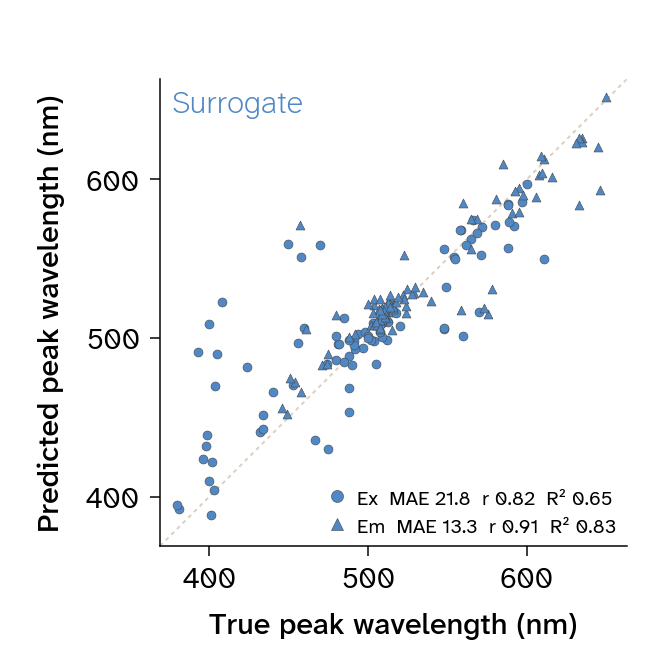

In [21]:
from matplotlib.lines import Line2D

EX_MARKER, EM_MARKER = "o", "^"


def plot_pred_scatter(name, m, color, fname):
    """True-vs-predicted peak wavelength for one model's test split. Excitation/emission are
    distinct marker shapes in the model's own colour; the legend carries MAE/r/R2 per peak,
    since the sweep's own selection metric (val MAE) averages over both and can hide a gap
    between them.
    """
    fig, ax = plt.subplots(figsize=(FULL_WIDE / 3 * PX, FULL_WIDE / 3 * PX))
    fig.subplots_adjust(left=0.24, right=0.94, bottom=0.18, top=0.88)

    lo, hi = min(m["P"].min(), m["T"].min()), max(m["P"].max(), m["T"].max())
    pad = 0.04 * (hi - lo)
    lim = (lo - pad, hi + pad)
    ax.plot(lim, lim, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=1, zorder=1)
    ax.scatter(m["T"][:, 0], m["P"][:, 0], s=20, marker=EX_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=1, zorder=2)
    ax.scatter(m["T"][:, 1], m["P"][:, 1], s=20, marker=EM_MARKER, color=color,
               ec=str(apc.charcoal), linewidths=0.3, alpha=1, zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_box_aspect(1)
    ax.set_xticks([400,500,600])
    ax.set_yticks([400,500,600])
    ax.set_xlabel("True peak wavelength (nm)"); ax.set_ylabel("Predicted peak wavelength (nm)")

    # Identity + config labelled in place (top-left, model colour) rather than an axes title --
    # in-figure titles are the caption's job per the guide.
    ax.annotate(f"{name}", xy=(0, 1), xycoords="axes fraction",
                xytext=(6, -6), textcoords="offset points", ha="left", va="top",
                **{**ANNOTATION, "fontsize": 16, "color": color})

    handles = [
        Line2D([], [], marker=EX_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Ex  MAE {m['ex']['mae']:.1f}  r {m['ex']['r']:.2f}  R² {m['ex']['r2']:.2f}"),
        Line2D([], [], marker=EM_MARKER, linestyle="none", markerfacecolor=color,
               markeredgecolor=str(apc.charcoal), markeredgewidth=0.3,
               label=f"Em  MAE {m['em']['mae']:.1f}  r {m['em']['r']:.2f}  R² {m['em']['r2']:.2f}"),
    ]
    # style_plot auto-detects any legend on the axes and calls the buggy style_legend() (stray
    # rule-under-title line, see notebook conventions) -- style the plot BEFORE adding the legend,
    # then style the legend by hand with the same two safe helpers style_legend uses.
    apc.mpl.style_plot(ax, monospaced_axes="both")
    leg = ax.legend(handles=handles, loc="lower right", fontsize=10, frameon=True,
                    handletextpad=0.5, borderpad=0.5, labelspacing=0.4)
    leg.get_frame().set_edgecolor("none"); leg.get_frame().set_alpha(0.85)
    apc.mpl.capitalize_legend_text(leg)
    apc.mpl.justify_legend_text(leg)

    fig.savefig(f"{FIGDIR}/{fname}.svg")
    fig.savefig(f"{FIGDIR}/{fname}.png", dpi=200)
    plt.show()


plot_pred_scatter("Surrogate", surr_test, HIGHLIGHT, "peak_surrogate_test_predictions")

**Figure 6. The deployed surrogate's held-out test predictions track the true peak reasonably
well, but excitation lags emission by 8.6 nm of MAE.** Predicted vs. true peak wavelength for CNN
(1) - max (ESM-2), refit on the full surrogate train+val pool (515 proteins) and evaluated once on
its 91-protein test split (untouched throughout CV, training, and refitting): excitation MAE 21.8
nm / r 0.82 / R² 0.65 vs. emission MAE 13.3 nm / r 0.91 / R² 0.83 (pooled 17.6 nm). That pooled
figure is slightly better than the three CV fold-models' own average on this same 91-row test set
(18.8 nm, Figure 4) — consistent with training on the full 515-row pool rather than two-thirds of
it per fold. The excitation/emission gap Figure 1 already flagged as a property of the landscape
itself shows up again here. Figure 7 is the oracle's own equivalent, on its own independent test
split.

## 7. Test-set predictions: the oracle

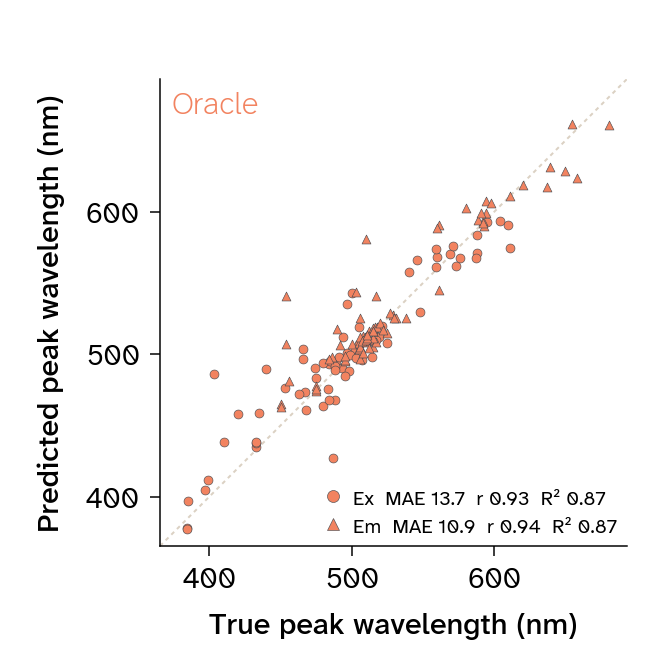

In [22]:
plot_pred_scatter("Oracle", oracle_test, CONTRAST, "peak_oracle_test_predictions")

**Figure 7. The oracle is better calibrated than the surrogate, and the excitation/emission gap
nearly closes.** Predicted vs. true peak wavelength for CNN (1) - max (ProstT5), the oracle
sweep's validation-selected winner (Figure 5), run once on its own 76-protein test split:
excitation MAE 13.7 nm / r 0.93 / R² 0.87 vs. emission MAE 10.9 nm / r 0.94 / R² 0.87 (pooled 12.3
nm) — both peaks land close together, unlike the surrogate's wider split in Figure 6. This mirrors
the oracle's own architecture sweep (Figure 5) beating its strongest null by a wider margin than
the surrogate's sweep did (8.0 nm vs. 4.7 nm, Figure 4) — a different pretrained encoder and a
different (nested) split, but consistently the stronger model of the two.

## 8. Guided design, cycle by cycle — against an unguided control

The question the archived task-1 notebook (`archive/visualization_task1_design.ipynb`) asks of the
original task set, asked again of an ordinary target: **does the guided search move a scaffold toward a target it was pointed at, and how much of
that movement is the guidance?** Two arms, on the same tasks:

- **Guided** ([`3.1_design_run_guided/run_task2_guided.py`](3.1_design_run_guided/run_task2_guided.py)): at
  each editable position the candidate substitutions are ESM-2's top 10 under the window's structural
  constraints, ranked by `z(logp_esm) − z(|Δex|) − z(|Δem|)` where the two error terms are the
  **surrogate's** distance to the target. 3 trials × 2 cycles per task, of which the figure draws
  the **final** cycle; the intermediate one is measured and printed beside it.
- **Unguided** ([`3.2_design_run_gibbs/run_task2_gibbs.py`](3.2_design_run_gibbs/run_task2_gibbs.py)):
  the same windows and the same proposal machinery with λ_ex = λ_em = 0 — Gibbs sampling from the
  ESM-2 masked LM with the surrogate removed from the loop. 12 trials × 2 cycles, of which the
  **first 3 are used** so both arms get the same number of draws per task; more trials shrink the
  error on a task's mean and stretch both tails for free, which would make the control differ for a
  reason that has nothing to do with guidance. The 12-trial means are printed alongside.
- **Unguided, surrogate-selected** — the same 12 unguided trials with the surrogate put back, but
  only *after* the search: rank a task's 12 final designs by the surrogate's own distance to the
  target and average the **top 3**. The guidance and the selection use the same model, so the pair
  of unguided groups separates what the surrogate is worth *inside* the loop from what it is worth
  as a filter over finished designs. It is the one group that is deliberately **not**
  budget-matched — picking 3 of 12 costs 12 draws — so it is read against the 12-trial control mean
  in the printout, not against the 3-trial group beside it.

A cycle is one pass over the scaffold's editable window: chromophore positions 1-2, then the 5 Å
pocket. What is plotted is neither arm's own opinion of itself but the **oracle's** distance to the
target, on the ProstT5 side of the pipeline and never consulted by either search: the mean of the two
absolute peak offsets, 0.5(|Δex| + |Δem|), in the same nm as the MAEs in Sections 6 and 7.
Round 0 is the unedited scaffold, so it is the distance each task started at and the bar everything
else has to beat.

Unlike the task-1 comparison, **no task has to be dropped**: both arms ran the same 36 + 36 pairs,
since task set 2's cohorts were merged when they were selected rather than when they are reported.

In [23]:
import glob

import score_traj_surrogate as sts    # the surrogate's per-round view, cached next to each arm
from itertools import combinations

from scipy.stats import ttest_rel, wilcoxon

# Two arms of the task-2 design stage, on the identical 72 tasks.
#
#   GUIDED     3.1_design_run_guided -- ESM-2 masked-LM proposals ranked with the SURROGATE's distance
#              to the target in the score. 72 tasks x 3 trials x 2 cycles.
#   UNGUIDED   3.2_design_run_gibbs -- the same windows, the same proposal machinery,
#              lam_ex = lam_em = 0: Gibbs sampling from the ESM-2 masked LM with the surrogate taken
#              out of the loop entirely. 72 tasks x 12 trials x 2 cycles.
#
# The conditions are the two cohorts curate_pairs_task2.py writes: S-pool, whose scaffolds are inside
# the deployed surrogate's train+val refit pool, and S-test, whose scaffolds it never saw.
CONDS = ["S-pool", "S-test"]
COHORT_LABEL = {"knownstruct_Spool": "S-pool", "knownstruct_Stest": "S-test"}
DTYPE = {"scaffold_name": str, "target_name": str}   # one dataset entry is literally named "11"


def load_arm(pipe, arm, cohorts=None):
    """Every trajectory of one arm, with the surrogate's own view of each round merged in.

    `peak_err` is the ORACLE's distance to the target as the design loop defines it -- the mean of
    the two absolute peak offsets, 0.5(|dex| + |dem|). `surr_err` is that same distance under the
    SURROGATE, which the design run never writes out (it logs only the accepted sequence),
    recomputed and cached by score_traj_surrogate.py.
    """
    frames = []
    for coh, label in (cohorts or COHORT_LABEL).items():
        for fn in sorted(glob.glob(os.path.join(str(pipe), coh, "design_*.csv"))):
            d = pd.read_csv(fn, dtype=DTYPE)
            d["cond"] = label
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    return df.merge(sts.compute(arm, verbose=False), on=["example", "trial", "round"], how="left")


guided = load_arm(dc.PIPE_OUT_ESM2_T2_R3, "esm2_t2_rand3")
unguided = load_arm(dc.PIPE_OUT_GIBBS_T2_R12, "gibbs_t2_r12")
# Both arms ran the same manifests, so this is an equality rather than an intersection -- assert it
# instead of silently taking whichever tasks happen to overlap.
assert set(guided.example) == set(unguided.example), "the two arms must cover the same tasks"
LAST = int(guided["round"].max())
assert int(unguided["round"].max()) == LAST, "the two arms must be compared at the same cycle"

TOP_K = 3


def top_k_by_surrogate(df, k=TOP_K):
    """A task's k best candidate designs as the SURROGATE ranks them -- a rule the search can apply,
    unlike ranking by oracle error, which would consult the held-out judge. The pool is every design
    the task produced, both cycles of every trial (6 guided, 24 unguided), since a candidate is a
    candidate whichever cycle it came out of.
    """
    return (df[df["round"] >= 1].sort_values("surr_err")
            .groupby("example", sort=False).head(k))


top3 = top_k_by_surrogate(guided)                 # the surrogate-selected top-3 series
FINAL_GUIDED = guided[guided["round"] == LAST]
FINAL_UNGUIDED = unguided[unguided["round"] == LAST]

# The control ran 12 trials to the guided arm's 3. A 12-trial group is not a like-for-like control:
# more draws shrink the error on a task's mean and stretch both tails for free. Figure 1 therefore
# uses the control's FIRST THREE trials, matching the guided arm's budget exactly; the 12-trial
# numbers are printed below for reference.
UNGUIDED_TRIALS = 3
FINAL_UNGUIDED_3 = FINAL_UNGUIDED[FINAL_UNGUIDED.trial < UNGUIDED_TRIALS]

# The fifth group, and the only one not budget-matched: the SURROGATE's top 3 of the control's 12
# final designs, averaged. It is what a campaign can do with an unguided sampler and the surrogate
# used purely as a FILTER over finished designs, as against the guided arm, which spends the same
# model inside the loop. The ranking rule is the same top-3-by-surrogate one, applied to the control's 12-design pool
# rather than the guided arm's; ranking by oracle error instead would consult the held-out judge and
# is not a rule a campaign could follow.
TOP3_UNGUIDED = top_k_by_surrogate(FINAL_UNGUIDED)

# THE DESIGN PAIR IS THE UNIT, NOT THE DESIGN. A task's trials are repeated draws on the same
# scaffold->target problem, so each group is summarised per task first -- the mean over its trials,
# with the SD across them carried alongside as that task's own uncertainty. Everything downstream
# (violins, dots, error bars, tests) is on these 36-per-condition numbers, not on 216 designs.
# Round 0 is the unedited scaffold, the same sequence in every trial, so its SD is fp16 batching
# noise (<= 0.2 nm) rather than a spread; in the selection group the SD is the spread over the three
# designs that were KEPT, not over repeated draws, since selection is part of what that method is.
#
# The guided arm appears at its FINAL cycle only. Every group in the figure then differs in kind --
# no edit, guided, unguided, unguided-then-filtered -- where cycle 1 differs from cycle 2 only in how
# far the same search was run, a question the aside printed below settles on its own. Dropping it
# takes the pairwise family from ten tests to six and empties the middle of the bracket stack.
GROUPS = ["Scaffold", "Guided", "Gibbs\nsampling", "Gibbs top 3\n(out of 12)"]
SOURCE = {GROUPS[0]: guided[guided["round"] == 0],
          GROUPS[1]: FINAL_GUIDED,
          GROUPS[2]: FINAL_UNGUIDED_3,
          GROUPS[3]: TOP3_UNGUIDED}
CYCLE1 = {c: guided[(guided["round"] == 1) & (guided.cond == c)].groupby("example").peak_err.mean()
          for c in CONDS}

PER_TASK, PER_TASK_SD = {}, {}
for c in CONDS:
    PER_TASK[c] = pd.DataFrame({g: df[df.cond == c].groupby("example").peak_err.mean()
                                for g, df in SOURCE.items()})
    PER_TASK_SD[c] = pd.DataFrame({g: df[df.cond == c].groupby("example").peak_err.std(ddof=1)
                                   for g, df in SOURCE.items()})
POINTS = {(c, g): PER_TASK[c][g].to_numpy() for c in CONDS for g in GROUPS}
POINT_SD = {(c, g): PER_TASK_SD[c][g].to_numpy() for c in CONDS for g in GROUPS}

# Paired across the 36 tasks of a condition, because every task appears in every group -- including
# against the scaffold, which is the comparison that asks whether a group moved at all. Wilcoxon
# signed-rank is printed beside the t-test as a distribution-free check and Holm across a condition's
# six tests guards the multiplicity; the figure annotates raw p and only where it clears ALPHA, so an
# unmarked pair is one the test could not separate.
TESTS = list(combinations(GROUPS, 2))
ALPHA = 0.05
PAIRED = {}
for c in CONDS:
    t = PER_TASK[c]
    for a, b in TESTS:
        d = t[a] - t[b]
        r = ttest_rel(t[a], t[b])
        PAIRED[(c, a, b)] = dict(n=len(t), diff=d.mean(), sd=d.std(ddof=1), t=r.statistic,
                                 df=len(t) - 1, p=r.pvalue, dz=d.mean() / d.std(ddof=1),
                                 p_wilcoxon=wilcoxon(t[a], t[b]).pvalue)
    # Holm: sort this condition's p values, scale each by (m - rank), keep the sequence monotone
    run = 0.0
    for rank, (p, a, b) in enumerate(sorted((PAIRED[(c, a, b)]["p"], a, b) for a, b in TESTS)):
        run = max(run, min(1.0, (len(TESTS) - rank) * p))
        PAIRED[(c, a, b)]["p_holm"] = run


def _flat(g):
    return g.replace("\n", " ")


print(f"{len(guided.example.unique())} tasks in both arms | guided {guided.trial.nunique()} trials, "
      f"unguided {unguided.trial.nunique()} ({UNGUIDED_TRIALS} used), {LAST} cycles each")
for c in CONDS:
    t, sd = PER_TASK[c], PER_TASK_SD[c]
    print(f"  {c} ({len(t)} tasks): " + " | ".join(f"{_flat(g)} {t[g].mean():.1f} nm" for g in GROUPS))
    print("    " + " | ".join(f"{_flat(g)} median {t[g].median():.1f}, quartiles "
                              f"{t[g].quantile(.25):.1f}-{t[g].quantile(.75):.1f}, mean trial SD "
                              f"{sd[g].mean():.1f}" for g in GROUPS[1:]))
    print("    tasks whose mean design beats the scaffold: "
          + ", ".join(f"{_flat(g)} {int((t[g] < t[GROUPS[0]]).sum())}/{len(t)}" for g in GROUPS[1:])
          + " | guided closer than "
          + ", ".join(f"{_flat(g)} on {int((t[GROUPS[1]] < t[g]).sum())}/{len(t)}" for g in GROUPS[2:]))
    u12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == c].groupby("example").peak_err.mean()
    print(f"    control on all 12 trials: {u12.mean():.1f} nm (the 3 used: {t[GROUPS[2]].mean():.1f}; "
          f"the surrogate's best 3 of the 12: {t[GROUPS[3]].mean():.1f})")
    # The cycle the figure leaves out, and the test that licenses leaving it out. Reported on its
    # own rather than inside the Holm family, which is over the four groups actually plotted.
    r1 = ttest_rel(CYCLE1[c], t[GROUPS[1]])
    print(f"    cycle 1, measured but not plotted: {CYCLE1[c].mean():.1f} nm -> cycle 2 "
          f"{t[GROUPS[1]].mean():.1f} ({CYCLE1[c].mean() - t[GROUPS[1]].mean():+.1f} nm, "
          f"t({len(t) - 1}) = {r1.statistic:+.2f}, p = {r1.pvalue:.2f})")

print(f"\npaired t-tests over per-pair means (n = {len(PER_TASK[CONDS[0]])} tasks per condition)")
for c in CONDS:
    print(f"  {c}")
    for a, b in TESTS:
        r = PAIRED[(c, a, b)]
        mark = "" if r["p"] < ALPHA else "   <- unmarked in the figure"
        print(f"    {_flat(a) + ' vs ' + _flat(b):30} {r['diff']:+7.1f} nm (SD {r['sd']:4.1f}) | "
              f"t({r['df']}) = {r['t']:+6.2f} | dz {r['dz']:+.2f} | p = {r['p']:.2g} "
              f"(Holm {r['p_holm']:.2g}, Wilcoxon {r['p_wilcoxon']:.2g}){mark}")

# Task set 1's counterpart numbers, for the cross-notebook read (README's three-arm table, same
# statistic: the per-task mean over trials at the final cycle, on the 72 tasks 3.2 and 3.3 share).
print("\nfor comparison, task set 1 (archive/visualization_task1_design.ipynb, ESM-2 guided vs Gibbs): "
      "scaffold 132.9 -> guided 91.4, unguided 105.8 nm")

72 tasks in both arms | guided 3 trials, unguided 12 (3 used), 2 cycles each
  S-pool (36 tasks): Scaffold 72.9 nm | Guided 38.4 nm | Gibbs sampling 47.7 nm | Gibbs top 3 (out of 12) 44.1 nm
    Guided median 26.7, quartiles 19.0-47.7, mean trial SD 12.0 | Gibbs sampling median 35.4, quartiles 23.4-65.8, mean trial SD 8.8 | Gibbs top 3 (out of 12) median 35.1, quartiles 15.2-71.2, mean trial SD 7.6
    tasks whose mean design beats the scaffold: Guided 35/36, Gibbs sampling 34/36, Gibbs top 3 (out of 12) 35/36 | guided closer than Gibbs sampling on 30/36, Gibbs top 3 (out of 12) on 22/36
    control on all 12 trials: 47.0 nm (the 3 used: 47.7; the surrogate's best 3 of the 12: 44.1)
    cycle 1, measured but not plotted: 39.7 nm -> cycle 2 38.4 (+1.2 nm, t(35) = +1.18, p = 0.25)
  S-test (36 tasks): Scaffold 67.4 nm | Guided 49.3 nm | Gibbs sampling 58.7 nm | Gibbs top 3 (out of 12) 58.3 nm
    Guided median 36.0, quartiles 25.6-61.5, mean trial SD 12.2 | Gibbs sampling median 48.5, qu

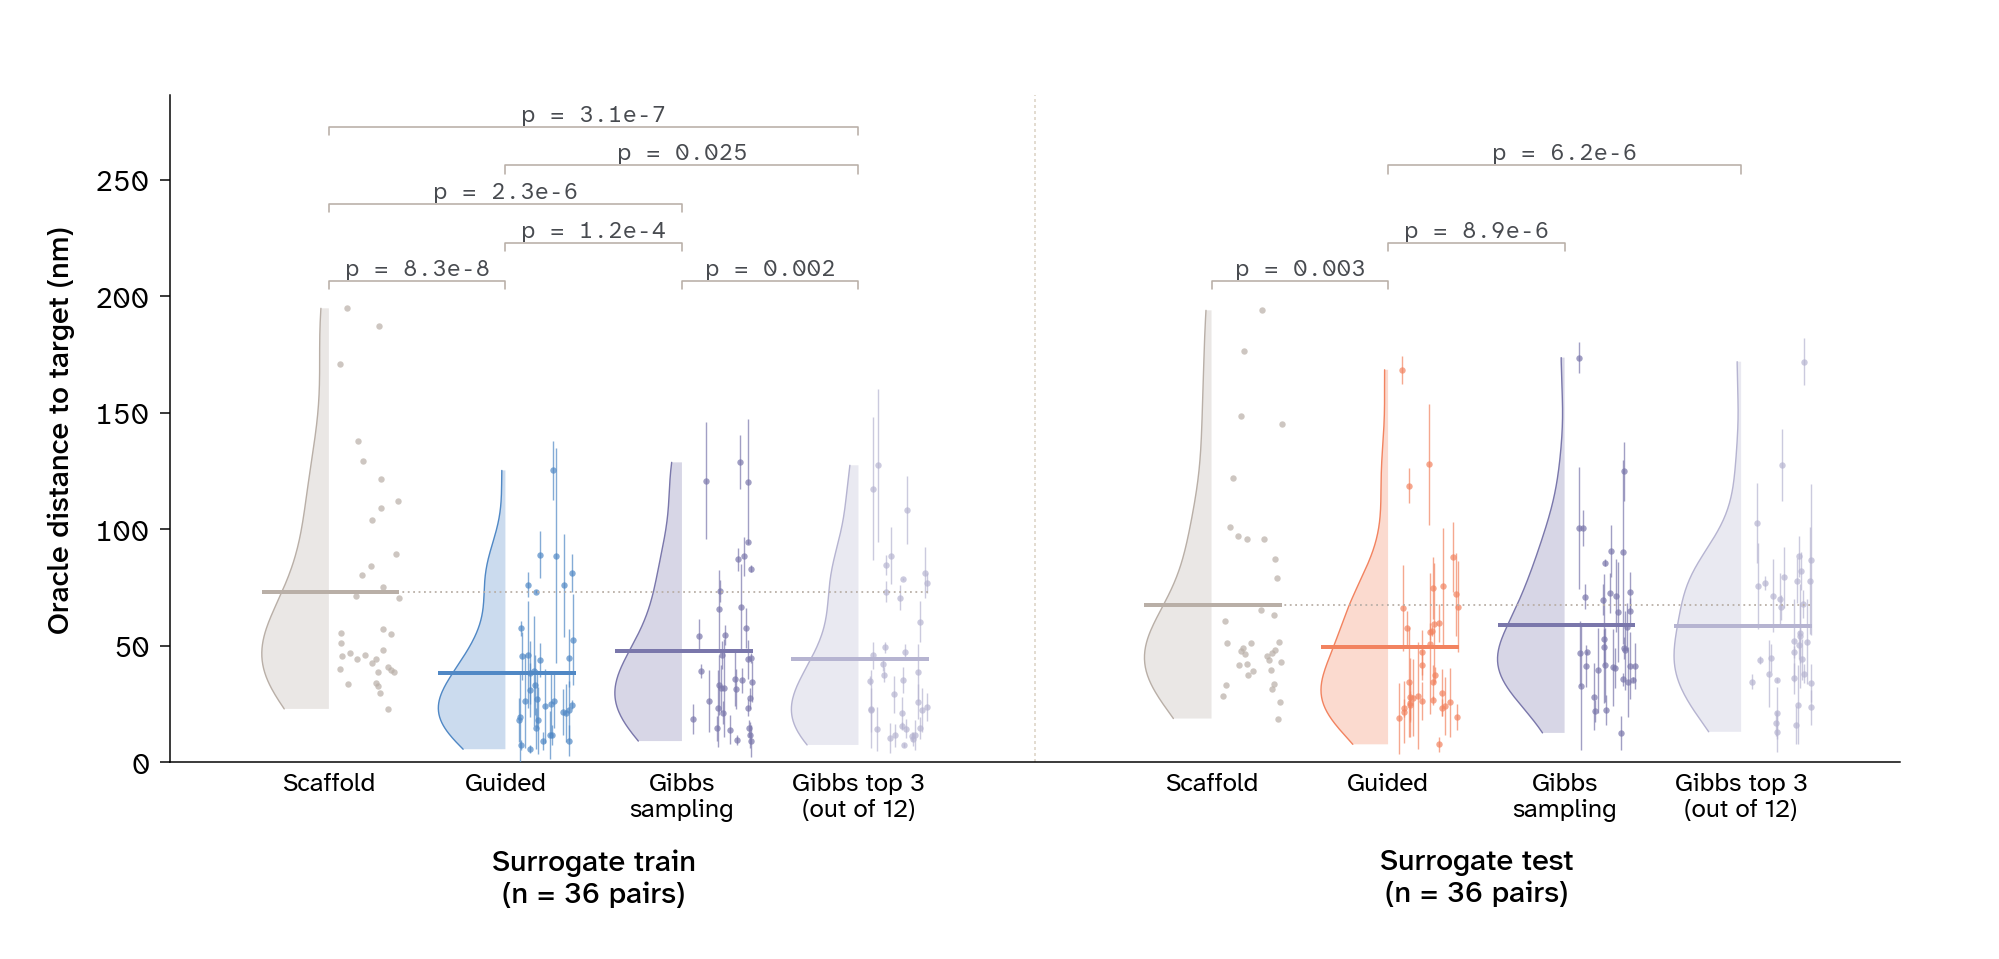

In [24]:
from matplotlib.colors import to_rgb
from scipy.stats import gaussian_kde

# One axis, two conditions, separated by a dashed rule. Within each condition the four groups are the
# unedited scaffold, the guided arm at its final cycle, the unguided control, and the surrogate's top
# 3 of that control's 12 final designs -- the same model as a post-hoc filter. Each group is drawn
# raincloud-style: a half violin on the left of its position and, on the right, one marker per design
# pair at that pair's mean over trials with a bar spanning +- 1 SD across them. The design pair is
# the unit throughout (the cell above says why), so a marker is a task rather than a design, and its
# bar is that task's own run-to-run uncertainty.
GAP = 1                                   # empty x-units between the two conditions
VIOLIN_W, STRIP_W, STRIP_PAD = 0.38, 0.34, 0.06
COND_COLOR = {CONDS[0]: HIGHLIGHT, CONDS[1]: CONTRAST}


def tint(color, f):
    """A fill: the series' own colour lightened towards the page, so markers stay on top of it."""
    return tuple(1 - f + f * c for c in to_rgb(color))


# Colour marks the ARM, not the group: the guided arm takes its condition's colour, both unguided
# groups take aster in both conditions (one series, read across the rule), and the scaffold stays
# neutral because it is the reference rather than a design. The selected group is the paler aster,
# the same family-and-tint convention the guided arm's own top 3 uses -- lightened less than for a
# bar, because here the colour has to survive being a 3 pt marker.
GROUP_COLOR = {GROUPS[0]: NEUTRAL, GROUPS[2]: CONTROL, GROUPS[3]: tint(CONTROL, 0.55)}


def half_violin(ax, x, v, color, width=VIOLIN_W, n=200):
    """Density of `v`, drawn to the left of `x` only.

    Evaluated between the group's own extremes (seaborn's cut=0 convention), so the violin never
    claims tasks where there are none, and scaled to a fixed maximum width, so violins are read
    against each other by shape rather than by area.
    """
    grid = np.linspace(v.min(), v.max(), n)
    dens = gaussian_kde(v)(grid)
    dens = dens / dens.max() * width
    # The curved side is stroked, the flat side is not: a rule down the group's own position would
    # read as an axis rather than as the edge of a density.
    ax.fill_betweenx(grid, x - dens, x, facecolor=tint(color, 0.30), edgecolor="none", zorder=2)
    ax.plot(x - dens, grid, color=color, lw=0.7, zorder=3)


fig, ax = plt.subplots(figsize=(FULL_WIDE * PX, 480 * PX))
fig.subplots_adjust(left=0.085, right=0.95, top=0.9, bottom=0.205)

rng = np.random.default_rng(RNG_SEED)
xpos = {}
for ci, cond in enumerate(CONDS):
    for gi, g in enumerate(GROUPS):
        x = ci * (len(GROUPS) + GAP) + gi
        xpos[(cond, g)] = x
        v, sd = POINTS[(cond, g)], POINT_SD[(cond, g)]
        col = GROUP_COLOR.get(g, COND_COLOR[cond])
        half_violin(ax, x, v, col)
        ax.errorbar(x + STRIP_PAD + rng.uniform(0, STRIP_W, len(v)), v, yerr=sd, fmt="o", ms=3.2,
                    color=col, ecolor=col, elinewidth=0.7, capsize=0, alpha=0.7, zorder=3)
        ax.plot([x - VIOLIN_W, x + STRIP_PAD + STRIP_W], [v.mean()] * 2, color=col, lw=2,
                solid_capstyle="butt", zorder=4)
    # Where the tasks started, carried across the condition's whole group so every violin can be
    # read against it without counting gridlines.
    x0, x1 = xpos[(cond, GROUPS[0])], xpos[(cond, GROUPS[-1])]
    ax.plot([x0 - VIOLIN_W, x1 + STRIP_PAD + STRIP_W], [POINTS[(cond, GROUPS[0])].mean()] * 2,
            ls=(0, (1, 2)), color=NEUTRAL, lw=0.9, zorder=5)

ax.axvline(0.5 * (xpos[(CONDS[0], GROUPS[-1])] + xpos[(CONDS[1], GROUPS[0])]),
           ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=1)

ax.set_xticks([xpos[(c, g)] for c in CONDS for g in GROUPS])
ax.set_xticklabels([g for c in CONDS for g in GROUPS], fontsize=13)
ax.set_xlim(-0.9, max(xpos.values()) + 0.9)
ax.set_ylabel("Oracle distance to target (nm)")

# The paired t-tests from the cell above, drawn over the two groups each one compares. Only the
# significant ones are drawn -- a bracket is a claim, and "we looked and found nothing" is the
# printout's job. A comparison keeps the SAME level in both conditions, so equal height means equal
# comparison and the two halves can be read against each other; a level is allotted only if the
# comparison is significant somewhere, which is why one side can show a gap where the other has a
# bracket.
#
# Levels are PACKED, not stacked one per comparison: shortest span first, and a bracket takes the
# lowest level it clears horizontally -- its label's width counted as part of it -- rather than
# always opening a new one. The two adjacent-group tests at opposite ends therefore share the bottom
# line, and the stack grows only where spans genuinely overlap: six comparisons in five levels.
Y_TOP_DATA = max((POINTS[k] + np.nan_to_num(POINT_SD[k])).max() for k in POINTS)
BR_Y0 = 1.06 * Y_TOP_DATA
BR_STEP = 0.085 * Y_TOP_DATA
LABEL_W, LABEL_GAP = 1.15, 0.3     # a "p = 1.2e-4" label and the clearance between two, in x units
left = lambda ab: min(GROUPS.index(ab[0]), GROUPS.index(ab[1]))
span = lambda ab: abs(GROUPS.index(ab[1]) - GROUPS.index(ab[0]))


def extent(ab):
    """The x-range a bracket occupies: its own span, widened where the centred label overhangs it."""
    lo, hi = left(ab), left(ab) + span(ab)
    mid = 0.5 * (lo + hi)
    return min(lo, mid - 0.5 * LABEL_W), max(hi, mid + 0.5 * LABEL_W)


rows, LEVEL = [], {}
for ab in sorted((ab for ab in TESTS if any(PAIRED[(c, *ab)]["p"] < ALPHA for c in CONDS)),
                 key=lambda ab: (span(ab), left(ab))):
    lo, hi = extent(ab)
    for i, row in enumerate(rows):
        if all(hi + LABEL_GAP <= l or lo >= h + LABEL_GAP for l, h in row):
            break
    else:
        rows.append([])
        i = len(rows) - 1
    rows[i].append((lo, hi))
    LEVEL[ab] = i
ax.set_ylim(0, BR_Y0 + (len(rows) - 1) * BR_STEP + 0.07 * Y_TOP_DATA)

for cond in CONDS:
    for (a, b), level in LEVEL.items():
        if PAIRED[(cond, a, b)]["p"] >= ALPHA:
            continue
        y = BR_Y0 + level * BR_STEP
        xa, xb = xpos[(cond, a)], xpos[(cond, b)]
        tick = 0.018 * Y_TOP_DATA
        ax.plot([xa, xa, xb, xb], [y - tick, y, y, y - tick], color=NEUTRAL, lw=0.8, zorder=6)
        p = PAIRED[(cond, a, b)]["p"]
        ax.annotate(f"p = {p:.3f}" if p >= 1e-3 else f"p = {p:.1e}".replace("e-0", "e-"),
                    xy=(0.5 * (xa + xb), y), xytext=(0, 1), textcoords="offset points",
                    ha="center", va="bottom", **{**NUMBER_NOTE, "fontsize": 11.5})

# Condition names sit under their own groups rather than in a key.
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
for cond in CONDS:
    xg = np.mean([xpos[(cond, g)] for g in GROUPS])
    note = "Surrogate train" if cond == CONDS[0] else "Surrogate test"
    ax.text(xg, -0.13, f"{note}\n(n = {len(PER_TASK[cond])} pairs)",
            transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/design_task2_rounds_distance_to_target.svg")
fig.savefig(f"{FIGDIR}/design_task2_rounds_distance_to_target.png", dpi=200)
plt.show()

**Figure 8. On an ordinary target the guidance is the whole of the difference between the arms; on
held-out scaffolds, unguided resampling stops working altogether — and so does using the surrogate
merely to pick the winners out of it.** Oracle distance to the target
for the 36 design pairs of each condition — scaffolds inside the surrogate's train ∪ val refit pool
(left of the dashed rule) and scaffolds held out from it (right). **The design pair is the unit:** a
task's trials are repeated draws on the same scaffold→target problem, so each group is summarised per
task first, and every marker is one pair at its mean over trials with a bar spanning ±1 SD across
them (mean trial SD 12.0-12.2 nm guided, 8.8-11.9 nm unguided). Each group is a raincloud: a half
violin (kernel density over the 36 per-pair means, clipped to their own extremes, scaled to a fixed
maximum width) with those markers beside it and the group mean as a rule across both halves; the
dotted line carries the scaffold mean across the condition. The groups are the unedited scaffold, the
guided arm at its **final cycle** — the intermediate cycle is measured and printed but not drawn,
for the reason in (iv) — the unguided control restricted to its **first 3 trials** so both arms have
the same budget — its 12-trial means, 47.0 and 59.9 nm, differ from the plotted 47.7 and 58.7 by about a
nanometre — and that same control **ranked by the surrogate**: the mean of its best 3 of 12 final
designs, which is the surrogate used as a filter over finished designs rather than inside the search.
The selected group is the one group deliberately not budget-matched, since picking 3 of 12 costs 12
draws, so it is read against the 12-trial mean rather than the 3-trial group beside it; its bars are
the spread over the three designs kept, not over repeated draws (mean 7.6 and 10.8 nm). Colour marks
the arm: guided takes its condition's colour, both unguided groups take aster on both sides with the
selected one paler, the scaffold stays neutral.

Brackets are **paired *t*-tests across the 36 pairs** of a condition, one for each of the six group
comparisons; only significant ones are drawn, with the exact *p*, and a comparison keeps the same
height in both halves, so a gap on one side means that test failed there. Brackets that do not
overlap horizontally share a level, so height says *which* comparison, not how strong it is — the
levels run shortest span at the bottom to longest at the top. Holm-adjusted *p* across each
condition's six tests and a Wilcoxon signed-rank check are in the cell's printout; Holm leaves every
verdict standing, and the one the distribution-free test does not support is the guided arm's 5.6 nm
margin over the selected control on S-pool (*p* = 0.025, Wilcoxon 0.088), read in (iii).

**(i) Both arms move on S-pool; only the guided arm moves on S-test.** Against the scaffold, the
guided final cycle gains 34.5 nm on S-pool (*t*(35) = +6.74, *p* = 8.3 × 10⁻⁸, *d*<sub>z</sub> =
+1.12) and 18.1 nm on held-out scaffolds (*p* = 0.0026, *d*<sub>z</sub> = +0.54). The control gains
25.3 nm on S-pool (*p* = 2.3 × 10⁻⁶) but only **8.7 nm on S-test, which the test cannot separate from
zero** (*p* = 0.13, hence no bracket): 21/36 held-out tasks improve without guidance, against 26/36
with it. This is the sharpest departure from task set 1, where the same control gained 23.7 and 30.6
nm and was decisive in both conditions. With targets a median 79 nm away instead of 190, resampling
the pocket no longer drifts toward the target for free — the free gain the unguided arm collected on
task set 1 was largely a consequence of extreme targets sitting far from the dataset's centre of
mass, which is exactly what a null is supposed to expose.

**(ii) What guidance buys is the same size in both conditions.** Guided minus unguided at the final
cycle is −9.2 nm on S-pool (*t*(35) = −4.33, *p* = 1.2 × 10⁻⁴, *d*<sub>z</sub> = −0.72) and −9.4 nm
on S-test (*t*(35) = −5.19, *p* = 8.9 × 10⁻⁶, *d*<sub>z</sub> = −0.87), with the guided arm closer on
30/36 and 28/36 pairs. The two conditions differ a great deal in their *outcome* (38.4 vs 49.3 nm)
but not at all in the guidance gap, and the same split appears in the arm that never loads the
surrogate. So the S-pool/S-test difference here is a property of the two cohorts' tasks, not evidence
that the surrogate exploits scaffolds it was trained on — task set 1's conclusion, reached from the
other direction.

**(iii) Ranking the control's designs with the surrogate recovers part of the guidance gap on
S-pool and none of it on held-out scaffolds.** Keeping the surrogate's best 3 of the control's 12
final designs improves on averaging all 12 by 3.0 nm on S-pool, 47.0 → 44.1 (*t*(35) = +2.47,
*p* = 0.018, *d*<sub>z</sub> = +0.41, better on 26/36 pairs), and by 1.7 nm on S-test, 59.9 → 58.3,
which the test cannot separate from zero (*p* = 0.13, 22/36). Against the budget-matched 3-trial
control the same selection is +3.6 nm (*p* = 0.0019) and +0.5 nm (*p* = 0.75). What that does to the
comparison the figure is about: on S-pool it cuts the guided arm's margin from 9.2 to 5.6 nm, a
bracket the *t*-test draws and Holm keeps (*p* = 0.025, *d*<sub>z</sub> = −0.39) but the
distribution-free Wilcoxon does not (0.088), and the guided arm is closer on only 22/36 pairs against 30/36 over the unselected control; on S-test
the margin is untouched at 9.0 nm (*t*(35) = −5.31, *p* = 6.2 × 10⁻⁶, *d*<sub>z</sub> = −0.89,
27/36). **The surrogate's ranking transfers no better than its predictions do** — it can pick winners
among designs built on scaffolds it was fitted on and cannot on scaffolds it was not — while the same
model spent *inside* the loop buys the same ~9 nm in both conditions (ii). Selection is also not a
repair for hard tasks: on S-pool it pulls the lower quartile from 25.8 to 15.2 nm and leaves the
upper one where it was (70.3 → 71.2), so it sharpens the pairs that were already working and finds
nothing to pick from on the ones that were not.

**(iv) Only the final cycle is drawn, because the second pass adds nothing measurable**, as on task
set 1: cycle 1 ends at 39.7 and 48.1 nm against the plotted 38.4 and 49.3, a difference of +1.2 nm on
S-pool (*p* = 0.25) and −1.2 nm on S-test (*p* = 0.46). With the window already visited once, a
second pass largely re-proposes what the first accepted. That test is printed in the cell above and
kept out of the Holm family, which is over the four groups the figure actually compares — groups that
differ in *kind* rather than in how far the same search was run.

**(v) Guidance removes bad outcomes rather than producing exceptional ones.** S-pool guided median
26.7 nm, quartiles 19.0-47.7, against the control's 35.4 and 23.4-65.8; S-test guided 36.0
(25.6-61.5) against 48.5 (40.2-71.7). The two lower quartiles are close — an unguided run lands the
occasional near-hit — and the arms separate in the upper half of the distribution.

**(vi) The residual is now within sight of the models' own error.** Designs end 38-49 nm from their
target where the oracle's held-out test MAE is 12.3 nm and the surrogate's is 17.6; task set 1 ended
at ~91 nm, about 7× the oracle's error. Half of these tasks also *start* within 50 nm, so there is
much less room between "unedited scaffold" and "as close as these two models can resolve" — which is
why 10 of the 36 held-out tasks end worse than they started even under guidance.

### 8.1 How often a single run improves on its scaffold, and by how much

The counts printed under Figure 8 — 35/36, 34/36, 26/36 — answer *how many design pairs improved* at
the one threshold nobody would defend, zero, and they answer it for a task's **average** draw. Both
halves of that are worth loosening. A design that ended a nanometre closer is not a success when the
oracle judging it has a 12.3 nm test error, and a campaign that can build three proteins cares what
one run returns, not what three of them average to. So this figure changes the unit to the
individual design at the final cycle — 3 per task, 108 per cohort, un-averaged — and sweeps the
threshold instead of fixing it.


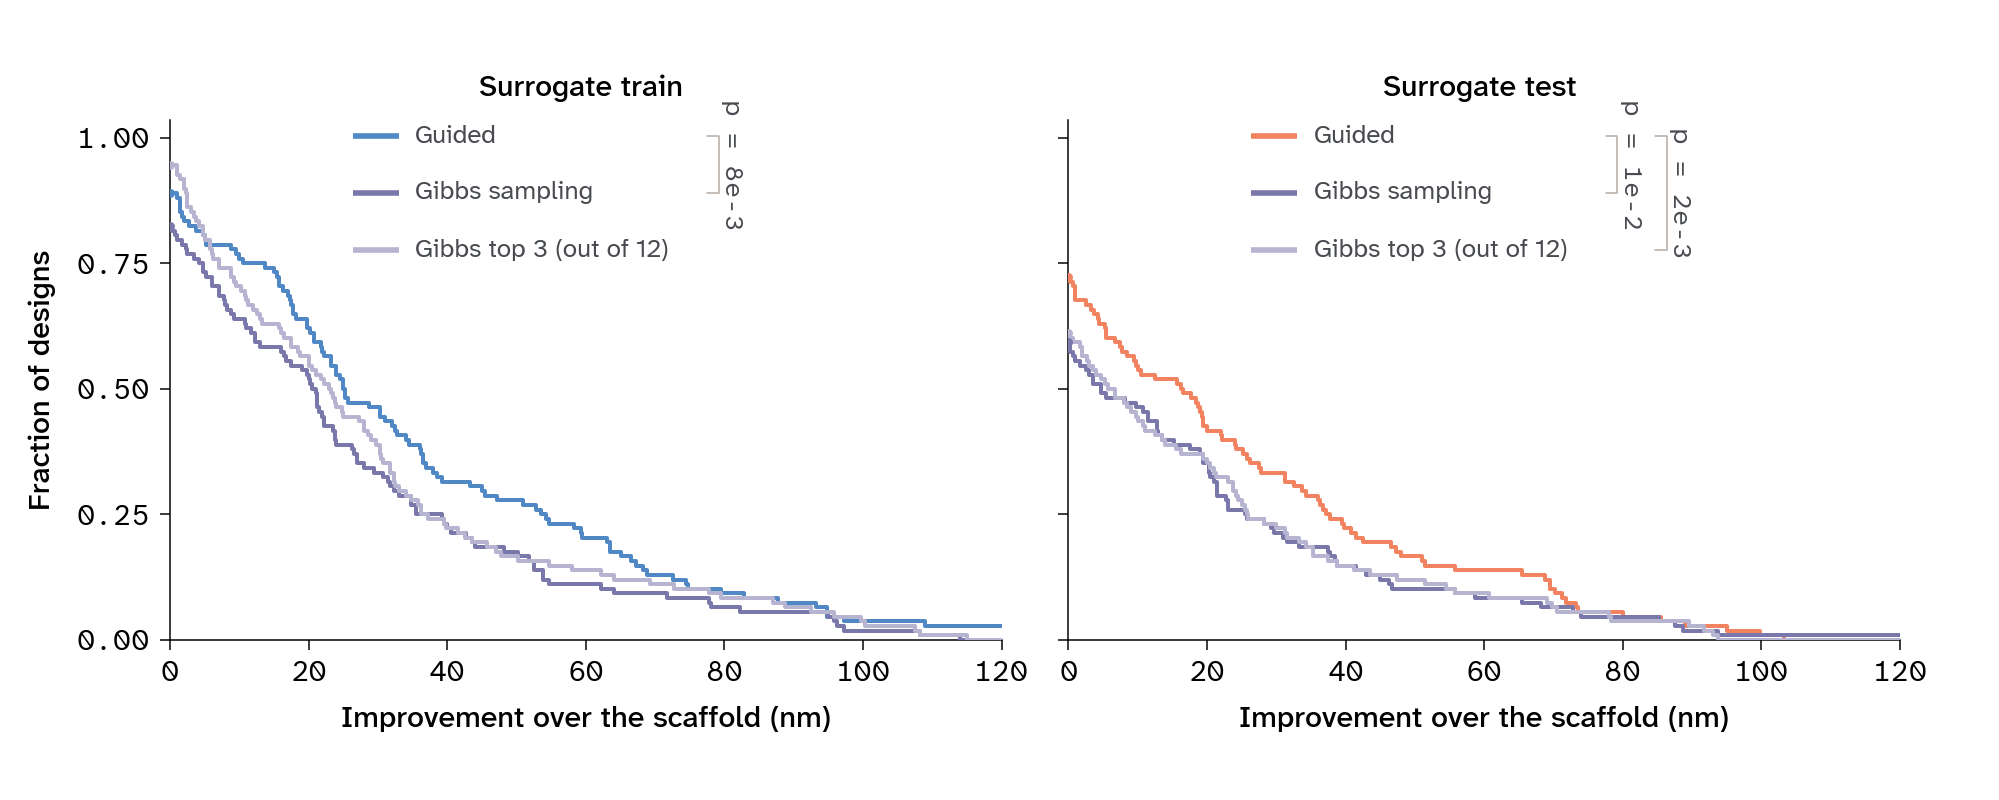

S-pool: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0nm: 0.89  >=  10nm: 0.76  >=  25nm: 0.50  >=  50nm: 0.28 | median  +24.9nm
    Gibbs sampling          n = 108 | >=   0nm: 0.82  >=  10nm: 0.64  >=  25nm: 0.39  >=  50nm: 0.18 | median  +20.6nm
    Gibbs top 3 (out of 12) n = 108 | >=   0nm: 0.94  >=  10nm: 0.70  >=  25nm: 0.44  >=  50nm: 0.17 | median  +23.0nm
    (all 12 trials)         n = 432 | >=   0nm: 0.83  >=  10nm: 0.63  >=  25nm: 0.41  >=  50nm: 0.19 | median  +20.2nm
S-test: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0nm: 0.72  >=  10nm: 0.54  >=  25nm: 0.38  >=  50nm: 0.17 | median  +16.3nm
    Gibbs sampling          n = 108 | >=   0nm: 0.59  >=  10nm: 0.46  >=  25nm: 0.26  >=  50nm: 0.10 | median   +4.6nm
    Gibbs top 3 (out of 12) n = 108 | >=   0nm: 0.61  >=  10nm: 0.44  >=  25nm: 0.27  >=  50nm: 0.12 | median   +6.0nm
    (all 12 trials)         n = 432 | >=   0nm: 0.59  >=  10n

In [25]:
# THE UNIT HERE IS THE DESIGN, NOT THE DESIGN PAIR -- the one figure in this notebook where it is.
# Figure 8 asks what a task's typical draw achieves and averages a task's trials to ask it; this asks
# how often a SINGLE RUN hands back something better than the scaffold it started from, which is the
# question a campaign faces when it can build only a handful of proteins. Averaging first would hide
# exactly what that question turns on: the spread between one task's own draws.
#
# Every design is taken at the FINAL cycle and measured against its own task's unedited scaffold (the
# round-0 mean, the same sequence in every trial to within fp16 noise). Each method contributes 3
# designs per task, 108 per cohort -- the guided arm's 3 trials, the control's first 3, and the 3 the
# surrogate picks out of the control's 12. Trial matching matters less here than in Figure 8: taking
# more draws does not shift a distribution over draws, it only estimates it better, and the printout
# carries the control's full 432 designs as a check on that. What the unit does cost is independence
# -- three designs from one task are three draws on one problem -- so the curve is a description of
# the draws, and any test run on it has to treat the task as the cluster.
#
# Both ways of demanding an improvement are computed here and each gets its own figure, because the
# two orderings differ: 18 nm is most of the way home for a design whose scaffold began 40 nm out and
# a rounding error for one that began 190 nm out. Figure 9 draws the demand in NANOMETRES, Figure 10
# the same thing as a SHARE of the distance that design's scaffold started at.
GAIN = {}
for c in CONDS:
    base = PER_TASK[c][GROUPS[0]]                    # each task's unedited scaffold
    for g in GROUPS[1:]:
        d = SOURCE[g][SOURCE[g].cond == c]
        b = base.loc[d.example].to_numpy()
        gain = b - d.peak_err.to_numpy()             # positive = closer than the scaffold began
        GAIN[(c, g)] = {"nm": gain, "pct": 100 * gain / b, "example": d.example.to_numpy()}


def by_task(cond, g, kind):
    """One row per design pair, one column per design: the shape the permutation null needs."""
    d = pd.DataFrame({"e": GAIN[(cond, g)]["example"], "v": GAIN[(cond, g)][kind]})
    return np.stack(d.groupby("e").v.apply(np.asarray).to_numpy())


# --- Do the curves really differ? --------------------------------------------------------------
# The generic test for two survival curves, assuming nothing about their shape: the two-sample
# KOLMOGOROV-SMIRNOV statistic D, the largest vertical gap between them, which is the quantity the
# figures are read for. There is no censoring here, so the survival-analysis machinery a log-rank
# test exists to handle -- and its proportional-hazards assumption -- buys nothing.
#
# Its textbook p value assumes independent observations and these are not: three designs come from
# one design pair. The null is therefore built by PERMUTATION, exchanging the arm labels of a pair's
# six designs within that pair and recomputing D. Every pair keeps three designs in each arm, so the
# resampling respects both the pairing (a pair appears in both arms) and the clustering (a pair's
# draws stay with it), and it assumes only that under the null it does not matter which arm produced
# which of that pair's designs. The test is run separately on each scale: the two differ by a
# per-task rescaling, which reorders the designs, so neither result implies the other.
N_PERM = 10000
TESTS_KS = [(GROUPS[1], GROUPS[2]), (GROUPS[1], GROUPS[3]), (GROUPS[2], GROUPS[3])]
rng_ks = np.random.default_rng(RNG_SEED)


def ks_D(a, b):
    """(largest vertical gap between the two survival curves, the improvement it occurs at)."""
    pooled = np.concatenate([a, b])
    order = np.argsort(pooled, kind="stable")
    step = np.concatenate([np.full(len(a), 1 / len(a)), np.full(len(b), -1 / len(b))])[order]
    run = np.cumsum(step)
    i = np.abs(run).argmax()
    return abs(run[i]), pooled[order][i]


def perm_p(A, B):
    """D, where it falls, and its permutation p, labels exchanged within a design pair."""
    d_obs, at = ks_D(A.ravel(), B.ravel())
    M, k = np.concatenate([A, B], axis=1), A.shape[1]
    hits = sum(ks_D(*(lambda p: (p[:, :k].ravel(), p[:, k:].ravel()))(rng_ks.permuted(M, axis=1)))[0]
               >= d_obs for _ in range(N_PERM))
    return d_obs, at, (hits + 1) / (N_PERM + 1)


def selection_p(cond, kind):
    """The filter needs a different null: its 3 designs are drawn from the same 12 the control's are,
    so an arm label is not exchangeable between them. The question it actually poses is whether
    ranking beats picking 3 of the 12 at random -- so the statistic is D between the selected sample
    and the pool it was selected from, and the null draws the 3 uniformly instead."""
    base = PER_TASK[cond][GROUPS[0]]
    d12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == cond]
    b12 = base.loc[d12.example].to_numpy()
    gain = b12 - d12.peak_err.to_numpy()
    pool = pd.DataFrame({"e": d12.example.to_numpy(),
                         "v": gain if kind == "nm" else 100 * gain / b12})
    P = np.stack(pool.groupby("e").v.apply(np.asarray).to_numpy())          # (pairs, 12)
    d_obs, at = ks_D(by_task(cond, GROUPS[3], kind).ravel(), P.ravel())
    hits = sum(ks_D(rng_ks.permuted(P, axis=1)[:, :3].ravel(), P.ravel())[0] >= d_obs
               for _ in range(N_PERM))
    return d_obs, at, (hits + 1) / (N_PERM + 1)


def ks_table(kind):
    """Every comparison on one scale, Holm-adjusted inside each cohort as everywhere else here."""
    out = {}
    for c in CONDS:
        for a, b in TESTS_KS:
            out[(c, a, b)] = (selection_p(c, kind) if (a, b) == TESTS_KS[2]
                              else perm_p(by_task(c, a, kind), by_task(c, b, kind)))
        run = 0.0
        for rank, (p, a, b) in enumerate(sorted((out[(c, a, b)][2], a, b) for a, b in TESTS_KS)):
            run = max(run, min(1.0, (len(TESTS_KS) - rank) * p))
            out[(c, a, b)] = (*out[(c, a, b)], run)
    return out


def p_text(p):
    """One significant figure in exponent form -- 0.0077 reads p = 8e-3 -- as Figure 8 writes its
    own small p values, and short enough to sit beside a bracket rather than beyond the next one."""
    return "p < 1e-4" if p < 1e-4 else "p = " + f"{p:.0e}".replace("e-0", "e-")


# --- The figure, drawn once per scale ------------------------------------------------------------
KEY_ROWS = (0.97, 0.86, 0.75)       # the three series, in axes fraction
KEY_SWATCH, KEY_LABEL_X = (0.22, 0.275), 0.295
BRACKET_X, KEY_TICK = (0.66, 0.72), 0.014


def improvement_curves(kind, grid, xlabel, stem):
    """Both cohorts' survival curves on one scale, with that scale's own tests marked in the key.

    No panel letters: each panel is titled with its cohort and the two are the same plot of the same
    quantity, so a letter would label a distinction the figure is not making.
    """
    ks = ks_table(kind)
    fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, 400 * PX), sharey=True)
    fig.subplots_adjust(left=0.085, right=0.95, top=0.85, bottom=0.2, wspace=0.08)

    for ci, cond in enumerate(CONDS):
        ax = axes[ci]
        apc.mpl.style_plot(ax, monospaced_axes="both")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for g in GROUPS[1:]:
            v = GAIN[(cond, g)][kind]
            col = GROUP_COLOR.get(g, COND_COLOR[cond])
            ax.plot(grid, (v[:, None] >= grid[None, :]).mean(0), drawstyle="steps-post",
                    color=col, lw=2, zorder=3, solid_joinstyle="round")
            # Where the curve starts: the plain "improved at all" share, the only point on the
            # curve that needs no threshold argued for.
            ax.plot([0], [(v > 0).mean()], marker="o", ms=4.5, color=col, zorder=4)
        ax.set_xlim(grid[0], grid[-1])
        ax.set_ylim(0, 1.035)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xlabel(xlabel)
        ax.set_title(f"Surrogate {'train' if cond == CONDS[0] else 'test'} ",
                     fontsize=plt.rcParams["axes.labelsize"], pad=12,
                     color=plt.rcParams["axes.labelcolor"])

        # The key is drawn by hand rather than by legend(), because it carries the test as well as
        # the colours: the three series stacked, and a BRACKET joining the pair whose curves the KS
        # test separates, labelled with its permutation p, exactly as Figure 8 brackets its groups.
        # Only significant comparisons are bracketed -- a bracket is a claim -- so an unbracketed
        # pair is one the test could not separate, and the printout carries every number either way.
        # A key per panel, since the guided arm keeps its condition's colour from Figure 8 and its
        # swatch is not the same on both sides.
        for row, g in zip(KEY_ROWS, GROUPS[1:]):
            ax.plot(KEY_SWATCH, [row] * 2, color=GROUP_COLOR.get(g, COND_COLOR[cond]), lw=2.8,
                    transform=ax.transAxes, clip_on=False, solid_capstyle="butt")
            ax.text(KEY_LABEL_X, row, g.replace("\n", " "), transform=ax.transAxes, ha="left",
                    va="center", fontsize=13, color=str(apc.charcoal))
        # Each comparison is placed differently rather than in a shared column: its p runs down the
        # right of ITS OWN bracket, centred on that bracket's span, so which pair a p belongs to is
        # read off its position and not only off the height of the bracket beside it. Turned on its
        # side the label is narrow enough that the outer bracket's line passes it without touching.
        for level, ab in enumerate(TESTS_KS[:2]):
            d, at, p, holm = ks[(cond, *ab)]
            if p >= ALPHA:
                continue
            x, y0, y1 = BRACKET_X[level], KEY_ROWS[0], KEY_ROWS[level + 1]
            ax.plot([x - KEY_TICK, x, x, x - KEY_TICK], [y0, y0, y1, y1], color=NEUTRAL, lw=0.8,
                    transform=ax.transAxes, clip_on=False)
            ax.text(x + 0.016, 0.5 * (y0 + y1), p_text(p), transform=ax.transAxes,
                    ha="center", va="center", rotation=270, **{**NUMBER_NOTE, "fontsize": 13})
        if ci == 0:
            ax.set_ylabel("Fraction of designs")

    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    return ks


def report(kind, marks, unit, ks):
    """The curves at the thresholds worth naming, and the tests behind the marks in the key.

    The control's own 12 trials close each block: if 3 draws describe the arm, the 432-design curve
    should sit on top of the 108-design one.
    """
    for c in CONDS:
        base = PER_TASK[c][GROUPS[0]]
        d12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == c]
        b12 = base.loc[d12.example].to_numpy()
        gain = b12 - d12.peak_err.to_numpy()
        pool = gain if kind == "nm" else 100 * gain / b12
        print(f"{c}: fraction of designs improved by at least ...")
        for g in list(GROUPS[1:]) + ["(all 12 trials)"]:
            v = pool if g == "(all 12 trials)" else GAIN[(c, g)][kind]
            print(f"    {_flat(g):23} n = {len(v):3d} | "
                  + "  ".join(f">= {t:>3}{unit}: {(v >= t).mean():.2f}" for t in marks)
                  + f" | median {np.median(v):+6.1f}{unit}")
    print(f"\ntwo-sample Kolmogorov-Smirnov, {N_PERM} permutations within design pair")
    for c in CONDS:
        print(f"  {c}")
        for a, b in TESTS_KS:
            d, at, p, holm = ks[(c, a, b)]
            note = ("  (vs the 12 it was picked from, against random picks)"
                    if (a, b) == TESTS_KS[2] else "")
            print(f"    {_flat(a) + ' vs ' + _flat(b):46} D = {d:.3f} at {at:+6.1f}{unit} | "
                  f"{p_text(p)} (Holm {holm:.4f}){note}")


KS_NM = improvement_curves("nm", np.linspace(0, 120, 481), "Improvement over the scaffold (nm)",
                           "design_task2_improved_vs_threshold")
report("nm", (0, 10, 25, 50), "nm", KS_NM)


**Figure 9. The guided arm's advantage over both controls is not an artefact of where the bar is
set — its curve runs above them at every threshold, and the difference survives a test that assumes
nothing about the curves' shape. Filtering the control's designs with the surrogate does something
different and narrower: on scaffolds the surrogate knows it removes outright failures, and it never
overtakes guidance for the larger moves.** The fraction of a cohort's designs that ended closer to
their target than the unedited scaffold they started from, by at least the improvement on the *x*
axis — **left**, scaffolds inside the surrogate's train ∪ val refit pool; **right**, scaffolds held
out from it.

**The unit is the individual design, not the design pair** — the one figure here where that is true.
Every design is taken at the final cycle and measured against its own task's scaffold, and each
method contributes 3 per task, 108 per cohort: the guided arm's 3 trials, the control's first 3, and
the 3 the surrogate picks out of the control's 12. Nothing is averaged over trials, so a curve
describes what one run returns rather than what three of them agree on. The control's own 12 trials
(432 designs) reproduce its 3-trial curve to within 0.02 at every threshold printed below, so the
truncation is not doing any work. Each curve starts at the dot — the plain "improved at all" share —
and falls to zero at that method's best design, so one method dominates another wherever its curve
runs above; a curve crosses 0.5 at that method's median improvement. Demanding a *share* of the
distance a design's scaffold started at, rather than nanometres, reorders the two controls; those
numbers are printed under the figure and read in (iii).

**The test is the two-sample Kolmogorov–Smirnov statistic** *D*, the largest vertical gap between
two curves, which is the assumption-free version of "one curve sits above the other" and needs
nothing of their shape. There is no censoring here, so the machinery a log-rank test exists to
handle, and its proportional-hazards assumption, would buy nothing. Its textbook *p* would be wrong
in the other direction, though: three designs come from one design pair, so the null is built by
permutation instead — exchanging the arm labels of a pair's six designs *within that pair*, 10,000
times, which respects both the pairing and the clustering. The filter needs a different null, since
its 3 designs are drawn from the same 12 the control's are and an arm label is not exchangeable
between them; there the statistic is *D* between the selected sample and the 12-design pool it came
from, against the same *D* when the 3 are picked at random. The key carries the verdict the way
Figure 8's brackets do: a bracket joins the two series a test separates, labelled with its
permutation *p* written to one significant figure, and **only significant comparisons are
bracketed** — an unbracketed pair is one the test could not separate. The filter's own test joins no
two curves, so it is not bracketed at all; it and every number behind the marks — *D*, where the
largest gap falls, and Holm across each cohort's three tests — are in the printout.

**(i) At a threshold of zero, filtering looks best and means least.** On S-pool the surrogate's top 3
improve at all on 0.94 of designs against the guided arm's 0.89 and the raw control's 0.82: ranking
12 finished designs is an effective way to *throw out the failures*, which is the one thing a
post-hoc filter can do without any ability to aim. Against random picks from the same 12 that
selection is decisive (*D* = 0.130, *p* < 0.0001), and the gap falls at +0.6 nm — precisely at the
improved/not-improved line, not out among the large moves. The ordering reverses as soon as the
demand exceeds a rounding error: by 10 nm it is 0.76 guided against 0.70 filtered, and it never
reverses back. On held-out scaffolds the filter cannot even do that much — 0.61 against the raw
control's 0.59, with the guided arm at 0.72, and selection no better than chance (*D* = 0.053,
*p* = 0.38).

**(ii) The guided arm leads at every threshold, and the whole-curve test agrees.** S-pool, guided /
Gibbs / Gibbs top 3: 0.76 / 0.64 / 0.70 at 10 nm, 0.50 / 0.39 / 0.44 at 25 nm, 0.28 / 0.18 / 0.17 at
50 nm; S-test 0.54 / 0.46 / 0.44, then 0.38 / 0.26 / 0.27, then 0.17 / 0.10 / 0.12. Against the raw
control the KS test separates the arms in both cohorts (*D* = 0.167, *p* = 0.008 on S-pool;
*D* = 0.148, *p* = 0.011 on S-test), and against the filtered control it separates them on held-out
scaffolds (*D* = 0.157, *p* = 0.002) but **not** on training-pool ones (*D* = 0.120, *p* = 0.11) —
the same verdict Figure 8 (iii) reaches from the pair-level means, reached here without averaging.
Median improvement is +24.9 nm guided against +20.6 and +23.0 on S-pool, and +16.3 nm against +4.6
and +6.0 on held-out scaffolds, the largest single-number gap in the figure.

**(iii) In relative terms the filter recovers most of the gap on S-pool and none of it on S-test.**
Closing at least a quarter of the scaffold's distance: 0.70 / 0.57 / 0.64 on S-pool against
0.49 / 0.36 / 0.34 on S-test; at half the distance, 0.49 / 0.32 / 0.42 and 0.30 / 0.17 / 0.19. Median
relative improvement is +47.3% / +29.4% / +38.9% on S-pool and +22.1% / +8.6% / +10.5% on S-test.
This is Figure 8 (iii) at the level of single runs: the surrogate ranks designs usefully on scaffolds
it was fitted on and not on scaffolds it was not.

**(iv) The failure rate is what the averages hide.** 11% of guided designs on training-pool scaffolds
end *further* from the target than the scaffold they started from, against 18% for the raw control
and 6% for the filtered one; on held-out scaffolds those become 28%, 41% and 39%. Figure 8 counts
26/36 held-out pairs as improved because averaging three draws rescues a task in which one draw was
bad — at the level of the run, that is not what a campaign would see.


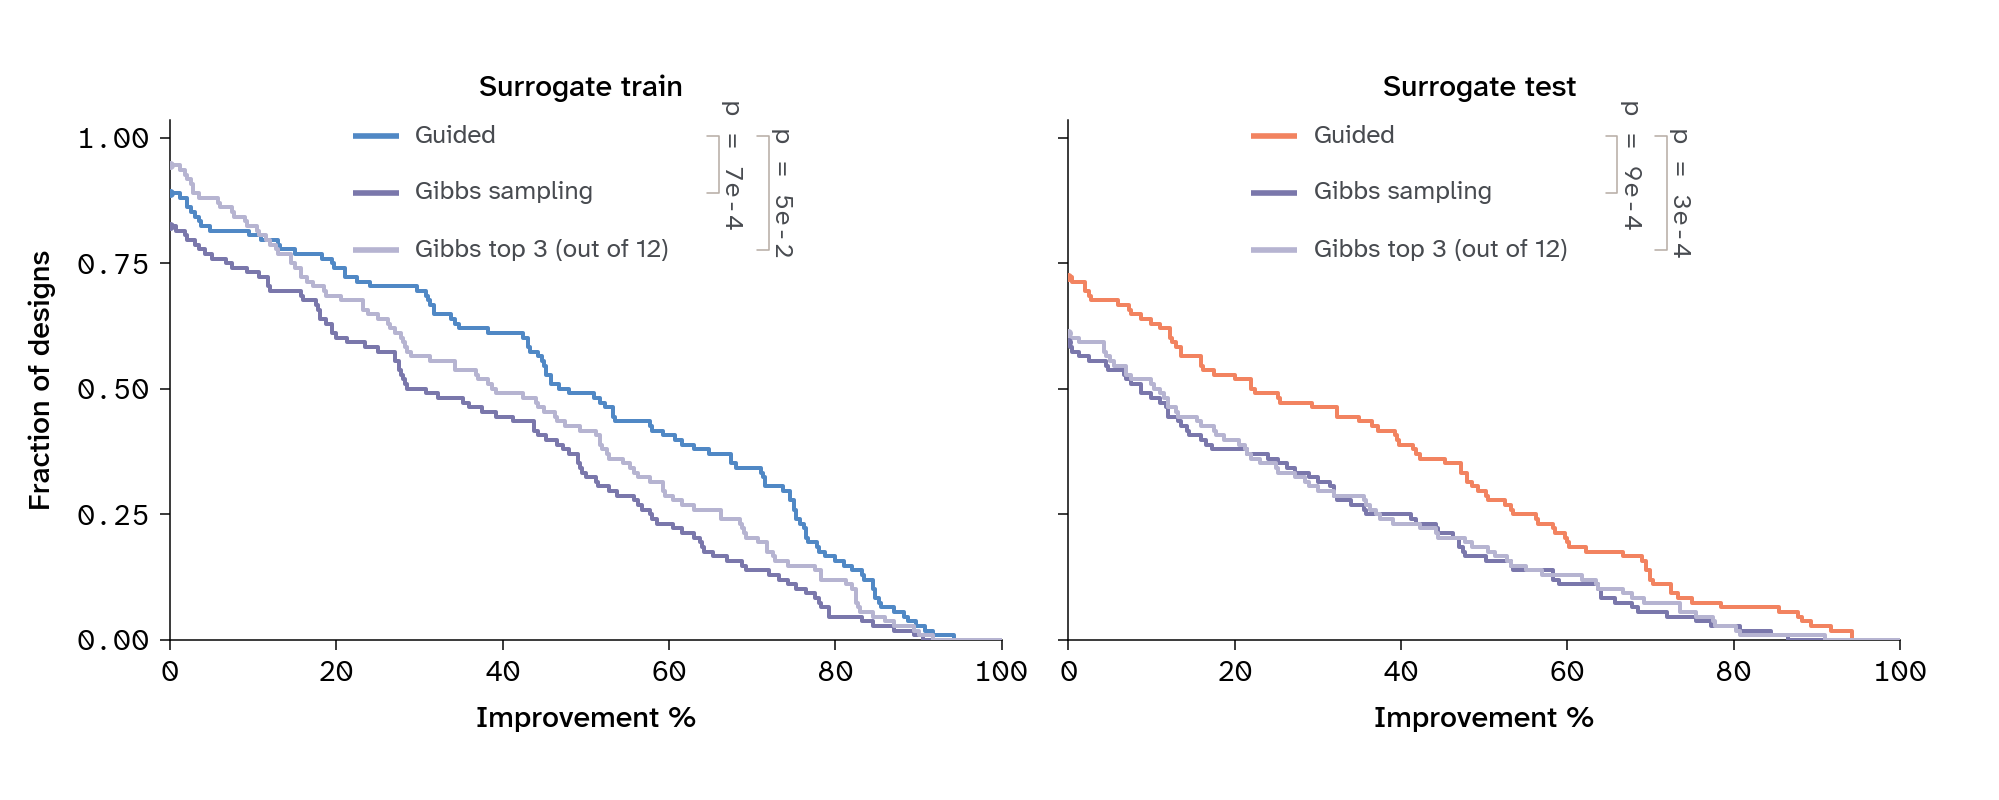

S-pool: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0%: 0.89  >=  25%: 0.70  >=  50%: 0.49  >=  75%: 0.26 | median  +47.3%
    Gibbs sampling          n = 108 | >=   0%: 0.82  >=  25%: 0.57  >=  50%: 0.32  >=  75%: 0.11 | median  +29.4%
    Gibbs top 3 (out of 12) n = 108 | >=   0%: 0.94  >=  25%: 0.64  >=  50%: 0.42  >=  75%: 0.15 | median  +38.9%
    (all 12 trials)         n = 432 | >=   0%: 0.83  >=  25%: 0.56  >=  50%: 0.35  >=  75%: 0.12 | median  +32.1%
S-test: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0%: 0.72  >=  25%: 0.49  >=  50%: 0.30  >=  75%: 0.07 | median  +22.1%
    Gibbs sampling          n = 108 | >=   0%: 0.59  >=  25%: 0.36  >=  50%: 0.17  >=  75%: 0.05 | median   +8.6%
    Gibbs top 3 (out of 12) n = 108 | >=   0%: 0.61  >=  25%: 0.34  >=  50%: 0.19  >=  75%: 0.06 | median  +10.5%
    (all 12 trials)         n = 432 | >=   0%: 0.59  >=  25%: 0.33  >=  50%: 0.16  >=  75%: 0.05

In [26]:
# The same figure with the demand expressed as a SHARE of the distance that design's scaffold
# started at, rather than in nanometres. Nothing about the designs changes; the x axis is rescaled
# per design pair, which reorders them -- a 20 nm move is 50% of a 40 nm gap and 10% of a 190 nm one
# -- so the curves are genuinely different curves and the tests are re-run rather than carried over.
KS_PCT = improvement_curves("pct", np.linspace(0, 100, 401),
                            "Improvement %",
                            "design_task2_improved_vs_threshold_pct")
report("pct", (0, 25, 50, 75), "%", KS_PCT)


**Figure 10. Asked for a share of the distance it had to travel rather than a number of nanometres,
the guided arm still leads: it closes more of each scaffold's gap to the target than either control,
on scaffolds the surrogate was fitted on and on scaffolds it never saw.** Figure 9 redrawn with the
demand on the *x* axis expressed as a percentage of the distance that design's own scaffold started
from its target — 0% is "no better than the scaffold it was built from", 100% is "landed on the
target exactly". The *y* axis is unchanged: the fraction of a cohort's designs that closed at least
that share of the gap, so a curve runs from the plain "improved at all" share on the left down to
zero at that method's best design, and one method beats another wherever its curve sits higher.
**Left**, scaffolds inside the surrogate's train ∪ val refit pool; **right**, scaffolds held out from
it.

Everything except the *x* axis is Figure 9's: the unit is the individual design at the final cycle,
each method contributing 3 per task and 108 per cohort — the guided arm's 3 trials (aegean on
S-pool, amber on S-test), the unguided control's first 3 (aster), and the 3 the surrogate picks
out of that control's 12 (pale aster) — with nothing averaged over trials. The rescaling is not
cosmetic, though: dividing by each pair's own starting distance reorders the designs, because 20 nm
is half of a 40 nm gap and a tenth of a 190 nm one. These are therefore different curves from Figure
9's, and every test behind them is re-run rather than carried over.

The typical guided design closes **47.3%** of its scaffold's gap on train-pool scaffolds and
**22.1%** on held-out ones, against 29.4% and 8.6% for unguided Gibbs sampling and 38.9% and 10.5%
for the surrogate's top 3 of 12. Closing at least half the gap: 0.49 of guided designs on train-pool
scaffolds against 0.32 unguided and 0.42 filtered, and 0.30 on held-out scaffolds against 0.17 and
0.19. The control's own 12 trials (432 designs) track its 3-trial curve to within 0.03 at every
threshold printed below, so the budget-matching does not shape the comparison.

Brackets carry the two-sample Kolmogorov–Smirnov test of Figure 9 — *D*, the largest vertical gap
between two curves, against a null that exchanges the arm labels of a design pair's six designs
*within that pair*, 10,000 times — labelled with the permutation *p* to one significant figure and
Holm-adjusted within each cohort; **only significant comparisons are bracketed**. On this scale the
guided arm separates from *both* controls in *both* cohorts, including from the filtered control on
train-pool scaffolds (*D* = 0.148, *p* = 0.049), which the nanometre axis of Figure 9 could not
separate (*p* = 0.11) — demanding a share of the journey is the harder test to pass by starting close
to the target. The filter's advantage remains concentrated where it means least: judged against
random picks from the same 12 designs it is decisive on train-pool scaffolds (*D* = 0.127,
*p* = 0.0003), but its largest gap falls at **+1.1%**, essentially at the improved/not-improved line,
and on held-out scaffolds it is indistinguishable from picking 3 at random (*D* = 0.049, *p* = 0.62).
Every number behind the marks, and the thresholds not named here, are in the printout.